# 06: TRAIN XGBOOST MODEL

This notebook trains XGBoost regression models to predict Land Surface Temperature (LST) from satellite and street-level imagery features. Two models are trained: a full model with GSV features and a deployment model using only raster features.

**Spatial integrity measures:**
- Leave-one-ward-out cross-validation prevents spatial autocorrelation leakage.
- Early stopping within CV uses a random split *inside the training fold*, never the held-out test fold.
- Final model training uses a spatially-separated ward (second-largest in CV set) for early stopping, not a random split that would break spatial boundaries.
- An Phu ward is held out entirely from CV and training as a final generalization test.

## MODULE SETUP

In [1]:
# Mount Google Drive.
from google.colab import drive
drive.mount("/content/drive")

import os

# Set working directory to project folder.
BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/hot_hem"
os.chdir(BASE_DIR)

print(f"Working directory: {BASE_DIR}")

Mounted at /content/drive
Working directory: /content/drive/MyDrive/Colab Notebooks/hot_hem


## IMPORT SETUP

In [2]:
from pathlib import Path
import pickle
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupKFold, train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb

# Set random seed for reproducibility.
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

## PATH CONFIGURATION

In [3]:
# Input paths.
TRAIN_FILE = Path("data/outputs/features/gsv_with_raster_features.csv")
SUPERCLASS_METRICS = Path("data/outputs/features/superclass_metrics.csv")

# Output paths.
MODEL_DIR = Path("models")
MODEL_DIR.mkdir(parents = True, exist_ok = True)

FULL_MODEL = MODEL_DIR / "xgboost_full_model.pkl"
DEPLOYMENT_MODEL = MODEL_DIR / "xgboost_deployment_model.pkl"
FEATURE_IMPORTANCE = MODEL_DIR / "feature_importance.csv"
CV_RESULTS = MODEL_DIR / "cv_results.csv"
DIAGNOSTICS_DIR = MODEL_DIR / "diagnostics"
DIAGNOSTICS_DIR.mkdir(parents = True, exist_ok = True)

print("PATH CONFIGURATION")
print(f"Training Data: {TRAIN_FILE}")
print(f"Model Directory: {MODEL_DIR}")
print(f"Diagnostics Directory: {DIAGNOSTICS_DIR}")

PATH CONFIGURATION
Training Data: data/outputs/features/gsv_with_raster_features.csv
Model Directory: models
Diagnostics Directory: models/diagnostics


## LOAD TRAINING DATA

In [4]:
# Load training data with raster features.
df = pd.read_csv(TRAIN_FILE)

print(f"Loaded {len(df)} training records.")
print(f"Columns: {list(df.columns)}")

# Define target variable.
TARGET = "lst_celsius"

print(f"Target Variable: {TARGET}")
print("Target Stats:")
print(df[TARGET].describe())

Loaded 20402 training records.
Columns: ['uid', 'lat', 'lon', 'heading', 'pct_other', 'pct_vegetation', 'pct_sky', 'pct_building', 'pct_pavement_road', 'pct_water', 'pct_vehicle_clutter', 'gvi', 'svi', 'bvi', 'hardscape_index', 'lst_kelvin', 'lst_celsius', 'ndvi', 'emissivity', 'palsar_hh_db', 'palsar_hv_db', 'palsar_hv_hh_ratio', 'palsar_glcm_contrast', 'palsar_glcm_homogeneity', 'palsar_glcm_energy', 'elevation_m', 'sky_view_factor', 'landcover_class']
Target Variable: lst_celsius
Target Stats:
count    20402.000000
mean        40.456578
std          1.551374
min         33.461755
25%         39.515039
50%         40.601984
75%         41.453088
max         46.539087
Name: lst_celsius, dtype: float64


## DEFINE FEATURE CATEGORIES

**Note:** Redundant features were removed:
- `gvi` (identical to `pct_vegetation`)
- `svi` (identical to `pct_sky`)
- `bvi` (identical to `pct_building`)
- `hardscape_index` (linear combination of urban features)

In [5]:
# Landsat features: thermal and vegetation indices.
LANDSAT_FEATURES = [
    "ndvi",
    "emissivity"
]

# PALSAR features: radar backscatter and texture.
PALSAR_FEATURES = [
    "palsar_hh_db",
    "palsar_hv_db",
    "palsar_hv_hh_ratio",
    "palsar_glcm_contrast",
    "palsar_glcm_homogeneity",
    "palsar_glcm_energy"
]

# DSM features: elevation and sky view factor.
DSM_FEATURES = [
    "elevation_m",
    "sky_view_factor"
]

# Landcover features.
LANDCOVER_FEATURES = [
    "landcover_class"
]

# GSV segmentation features: direct superclass percentages.
# NOTE: Removed gvi, svi, bvi as they are identical to pct_vegetation, pct_sky, pct_building.
# NOTE: Removed hardscape_index as it is a linear combination of other features.
GSV_SEGMENTATION_FEATURES = [
    "pct_vegetation",
    "pct_sky",
    "pct_building",
    "pct_pavement_road",
    "pct_water",
    "pct_vehicle_clutter",
    "pct_other"
]

# Shared features: available for both GSV points and network nodes (raster-only).
SHARED_FEATURES = (
    LANDSAT_FEATURES +
    PALSAR_FEATURES +
    DSM_FEATURES +
    LANDCOVER_FEATURES
)

# GSV-only features: only available at GSV sample points.
GSV_ONLY_FEATURES = GSV_SEGMENTATION_FEATURES

# All features for full model.
ALL_FEATURES = SHARED_FEATURES + GSV_ONLY_FEATURES

print("FEATURE CATEGORIES")
print(f"Shared Features (Raster Only): {len(SHARED_FEATURES)}")
print(f"GSV-only Features: {len(GSV_ONLY_FEATURES)}")
print(f"Total Features: {len(ALL_FEATURES)}")

FEATURE CATEGORIES
Shared Features (Raster Only): 11
GSV-only Features: 7
Total Features: 18


## ASSIGN WARD LABELS FROM BOUNDARY FILE

In [6]:
import geopandas as gpd
from shapely.geometry import Point

# Load ward boundaries.
BOUNDARY_FILE = Path("data/inputs/boundaries/aoi_wards.geojson")
gdf_wards = gpd.read_file(BOUNDARY_FILE)

print(f"Loaded {len(gdf_wards)} ward boundaries.")
print(f"Ward Column: ENGNAME_3.")
print(f"Available Wards: {gdf_wards['ENGNAME_3'].unique().tolist()}.")

# Apply 500m buffer to wards.
# First convert to projected CRS for accurate buffering.
gdf_wards_utm = gdf_wards.to_crs("EPSG:32648")  # UTM Zone 48N for HCMC.
gdf_wards_utm["geometry"] = gdf_wards_utm.geometry.buffer(500)
gdf_wards_buffered = gdf_wards_utm.to_crs("EPSG:4326")

# Convert training data to GeoDataFrame.
geometry = [Point(lon, lat) for lon, lat in zip(df["lon"], df["lat"])]
gdf_train = gpd.GeoDataFrame(df, geometry = geometry, crs = "EPSG:4326")

print(f"GeoDataFrame with {len(gdf_train)} points.")

# Spatial join to assign ward labels.
# Use 'first' to handle points that fall in multiple buffered wards.
gdf_joined = gpd.sjoin(
    gdf_train,
    gdf_wards_buffered[["ENGNAME_3", "geometry"]],
    how = "left",
    predicate = "within"
)

# Handle duplicate matches by keeping only the first ward.
gdf_joined = gdf_joined.groupby(gdf_joined.index).first().reset_index(drop = True)

# Extract ward column.
df["ward"] = gdf_joined["ENGNAME_3"].values

# Report assignment results.
assigned = df["ward"].notna().sum()
unassigned = df["ward"].isna().sum()

print("WARD ASSIGNMENT RESULTS")
print(f"Points assigned to ward: {assigned} ({assigned/len(df)*100:.1f}%)")
print(f"Points unassigned: {unassigned} ({unassigned/len(df)*100:.1f}%)")
print("Points per ward:")
print(df["ward"].value_counts())

# Filter to only points with ward assignments for spatial CV.
if unassigned > 0:
    print(f"NOTE: {unassigned} points outside buffered wards will be excluded from spatial CV.")
    df = df[df["ward"].notna()].copy()
    print(f"Filtered to {len(df)} points with ward assignments.")

Loaded 37 ward boundaries.
Ward Column: ENGNAME_3.
Available Wards: ['Ben Nghe', 'Ben Thanh', 'Caukho', 'Cau Ong Lanh', 'Co Giang', 'Da Kao', 'Nguyen Cu Trinh', 'Nguyen Thai Binh', 'Pham Ngu Lao', 'Tan Dinh', 'An Khanh', 'An Loi Dong', 'An Phu', 'Binh An', 'Binh Khanh', 'Binh Trung Dong', 'Binh Trung Tay', 'Cat Lai', 'Thanh My Loi', 'Thao Dien', 'Thu Thiem', 'Ward 1', 'Ward 10', 'Ward 11', 'Ward 12', 'Ward 13', 'Ward 14', 'Ward 15', 'Ward 16', 'Ward 2', 'Ward 3', 'Ward 4', 'Ward 5', 'Ward 6', 'Ward 7', 'Ward 8', 'Ward 9'].
GeoDataFrame with 20402 points.
WARD ASSIGNMENT RESULTS
Points assigned to ward: 20402 (100.0%)
Points unassigned: 0 (0.0%)
Points per ward:
ward
An Phu          5313
Ben Nghe        2035
Ben Thanh       1835
Thao Dien       1747
Ward 5          1430
Ward 10         1249
Caukho          1048
Ward 4          1037
Ward 14          830
Ward 12          801
Ward 6           784
Binh An          633
Cau Ong Lanh     606
An Khanh         517
Ward 15          400
Ward 11   

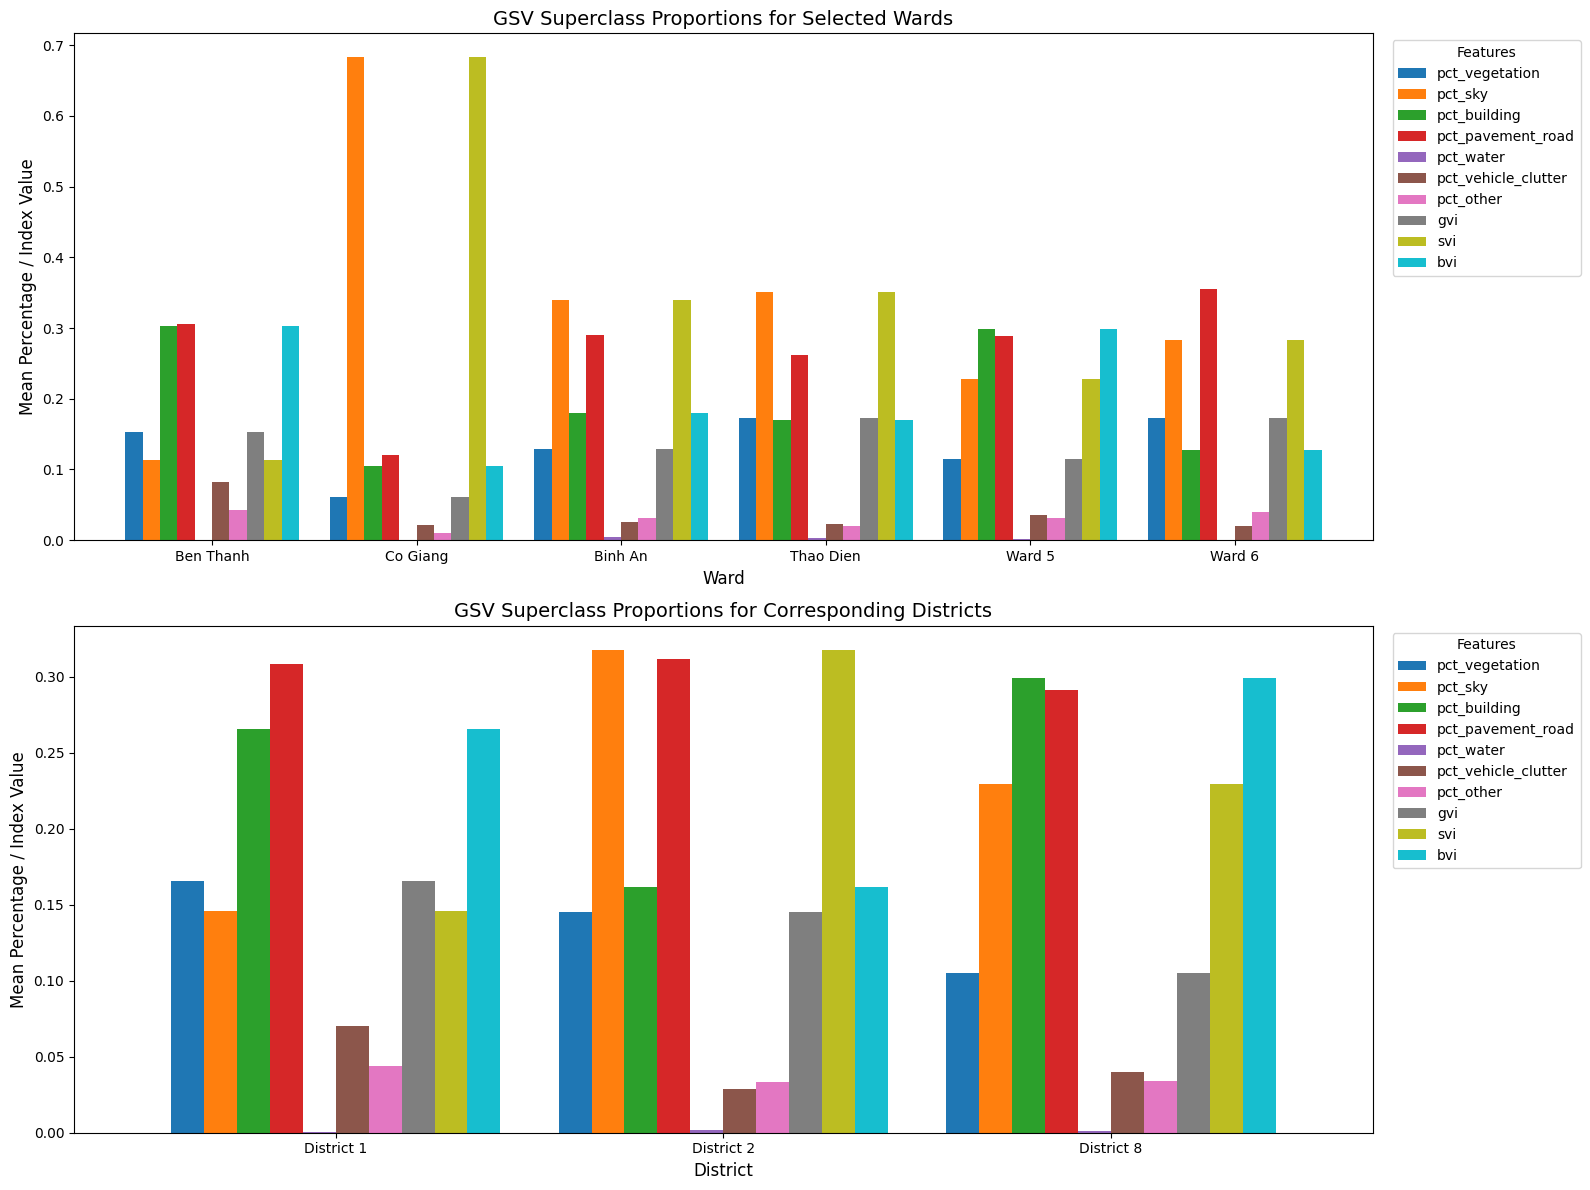

In [7]:
# Define the target wards based on the prompt
target_wards = ["Ben Thanh", "Co Giang", "Binh An", "Thao Dien", "Ward 5", "Ward 6"]

# Combine the requested feature lists
features_to_plot = GSV_SEGMENTATION_FEATURES + ["gvi", "svi", "bvi"]
#features_to_plot = GSV_SEGMENTATION_FEATURES
#features_to_plot = ["gvi", "svi", "bvi"]

# Ensure district mapping exists
if "district" not in df.columns:
    if "ENGNAME_2" in gdf_wards.columns:
        ward_to_district = dict(zip(gdf_wards["ENGNAME_3"], gdf_wards["ENGNAME_2"]))
        df["district"] = df["ward"].map(ward_to_district)

# Identify the districts for the target wards
target_districts = df[df["ward"].isin(target_wards)]["district"].dropna().unique().tolist()

# Compute the mean of the features for the target wards
ward_means = df[df["ward"].isin(target_wards)].groupby("ward")[features_to_plot].mean()

# Order wards logically (grouped by district)
ordered_wards = []
for dist in target_districts:
    dist_wards = df[(df["district"] == dist) & (df["ward"].isin(target_wards))]["ward"].unique().tolist()
    ordered_wards.extend(sorted(dist_wards))
ward_means = ward_means.reindex(ordered_wards)

# Compute the mean of the features for the corresponding districts
dist_means = df[df["district"].isin(target_districts)].groupby("district")[features_to_plot].mean()

# Create the plot with two subplots (2 rows, 1 column)
fig, axes = plt.subplots(nrows = 2, ncols = 1, figsize = (16, 12))

# Plot Wards (Top)
ward_means.plot(kind = "bar", ax = axes[0], width = 0.85)
axes[0].set_title("GSV Superclass Proportions for Selected Wards", fontsize = 14)
axes[0].set_ylabel("Mean Percentage / Index Value", fontsize = 12)
axes[0].set_xlabel("Ward", fontsize = 12)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation = 0)
# Move legend outside the plot area
axes[0].legend(title = "Features", bbox_to_anchor = (1.01, 1), loc = "upper left")

# Plot Districts (Bottom)
dist_means.plot(kind = "bar", ax = axes[1], width = 0.85)
axes[1].set_title("GSV Superclass Proportions for Corresponding Districts", fontsize = 14)
axes[1].set_ylabel("Mean Percentage / Index Value", fontsize = 12)
axes[1].set_xlabel("District", fontsize = 12)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation = 0)
# Move legend outside the plot area
axes[1].legend(title = "Features", bbox_to_anchor = (1.01, 1), loc = "upper left")

plt.tight_layout()
plt.savefig(DIAGNOSTICS_DIR / "combined_proportions.png", dpi = 300, bbox_inches = "tight")
plt.show()

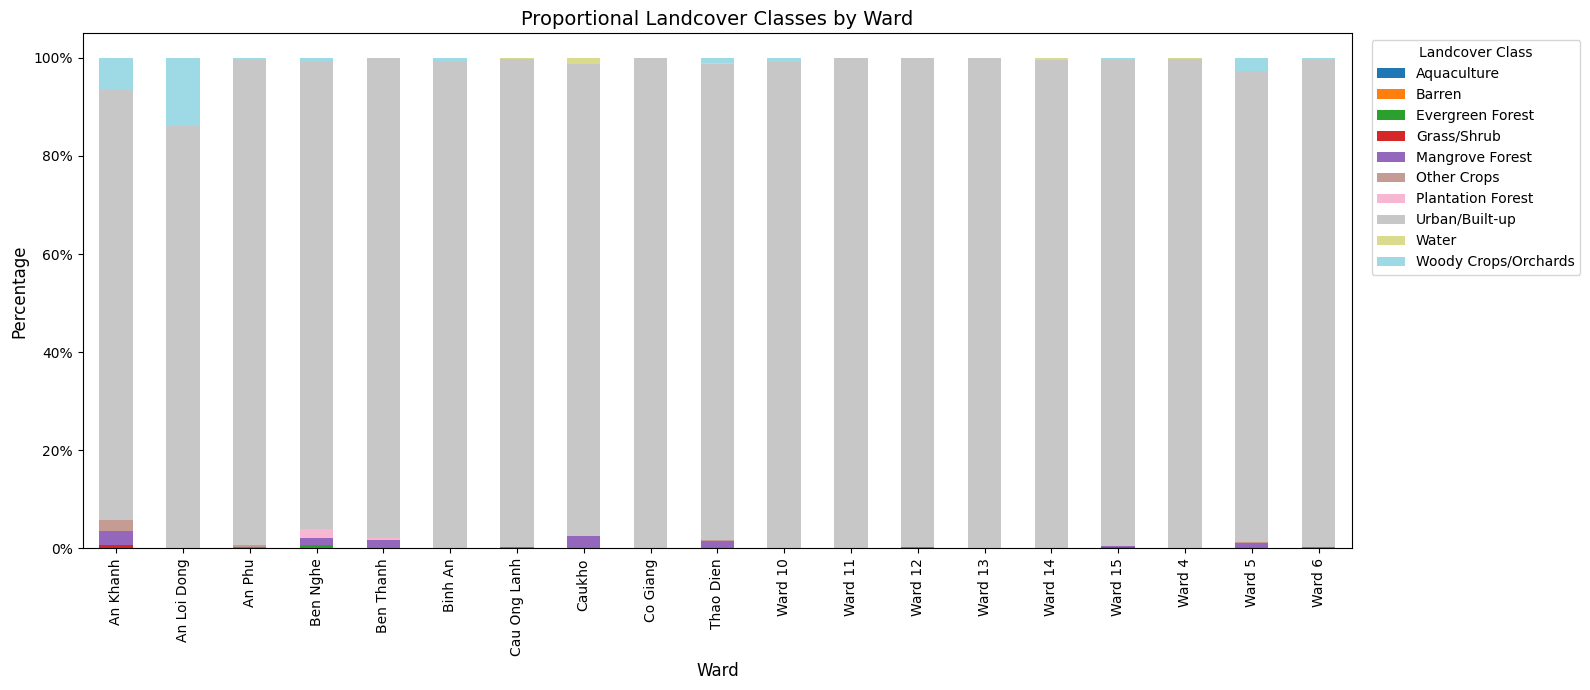

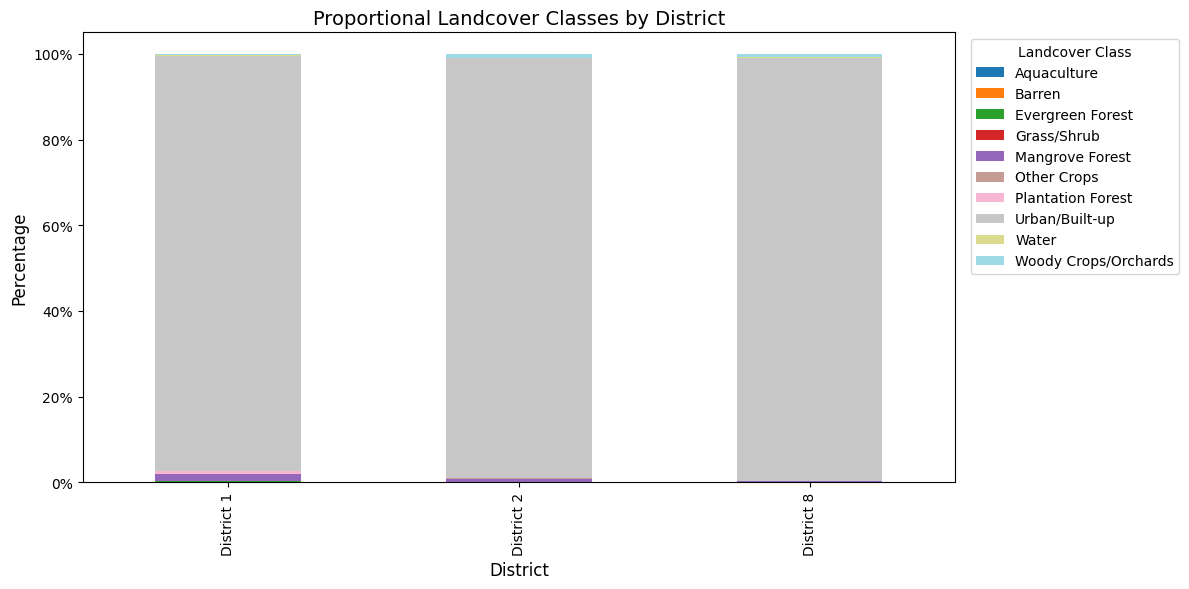

In [8]:
import matplotlib.ticker as mtick

# Define landcover mapping.
landcover_labels = {
    1.0: "Water",
    2.0: "Urban/Built-up",
    3.0: "Rice",
    4.0: "Other Crops",
    5.0: "Grass/Shrub",
    6.0: "Woody Crops/Orchards",
    7.0: "Barren",
    8.0: "Evergreen Forest",
    9.0: "Deciduous Forest",
    10.0: "Plantation Forest",
    11.0: "Mangrove Forest",
    12.0: "Aquaculture"
}

# Map labels to the dataframe.
df["landcover_name"] = df["landcover_class"].map(landcover_labels)

# Create mapping from ward to district using the already loaded gdf_wards.
if "ENGNAME_2" in gdf_wards.columns:
    ward_to_district = dict(zip(gdf_wards["ENGNAME_3"], gdf_wards["ENGNAME_2"]))
    df["district"] = df["ward"].map(ward_to_district)
else:
    print("Column ENGNAME_2 not found in gdf_wards. Cannot map districts.")

# Proportional Chart for Wards
# Calculate percentages (normalize=True) and multiply by 100.
ward_lc_props = df.groupby("ward")["landcover_name"].value_counts(normalize = True).unstack().fillna(0) * 100

fig, ax1 = plt.subplots(figsize = (16, 7))
ward_lc_props.plot(kind = "bar", stacked = True, ax = ax1, colormap = "tab20")
ax1.set_title("Proportional Landcover Classes by Ward", fontsize = 14)
ax1.set_ylabel("Percentage", fontsize = 12)
ax1.set_xlabel("Ward", fontsize = 12)
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
ax1.legend(title = "Landcover Class", bbox_to_anchor = (1.01, 1), loc = "upper left")
plt.tight_layout()
plt.show()

# Proportional Chart for Districts
if "district" in df.columns and df["district"].notna().any():
    dist_lc_props = df.groupby("district")["landcover_name"].value_counts(normalize = True).unstack().fillna(0) * 100

    fig, ax2 = plt.subplots(figsize = (12, 6))
    dist_lc_props.plot(kind = "bar", stacked = True, ax = ax2, colormap = "tab20")
    ax2.set_title("Proportional Landcover Classes by District", fontsize = 14)
    ax2.set_ylabel("Percentage", fontsize = 12)
    ax2.set_xlabel("District", fontsize = 12)
    ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax2.legend(title = "Landcover Class", bbox_to_anchor = (1.01, 1), loc = "upper left")
    plt.tight_layout()
    plt.savefig(DIAGNOSTICS_DIR / "lulc_proportions.png", dpi = 300, bbox_inches = "tight")
    plt.show()

## PREPARE TRAINING DATA

In [9]:
# Filter to rows with valid target.
df_train = df[df[TARGET].notna()].copy()

print(f"Samples with Valid LST: {len(df_train)} / {len(df)} ({len(df_train)/len(df)*100:.1f}%).")

# Check available features.
available_all = [f for f in ALL_FEATURES if f in df_train.columns]
available_shared = [f for f in SHARED_FEATURES if f in df_train.columns]

print("Available Features:")
print(f"Full Model: {len(available_all)} / {len(ALL_FEATURES)}.")
print(f"Deployment Model: {len(available_shared)} / {len(SHARED_FEATURES)}.")

# Show missing features.
missing_all = set(ALL_FEATURES) - set(available_all)
if missing_all:
    print(f"Missing Features: {missing_all}")

# Update feature lists to available features.
ALL_FEATURES = available_all
SHARED_FEATURES = available_shared

# Check feature completeness.
print("FEATURE COMPLETENESS")
for feat in ALL_FEATURES:
    if feat in df_train.columns:
        completeness = df_train[feat].notna().sum() / len(df_train) * 100
        print(f"{feat:35s}: {completeness:5.1f}%.")

Samples with Valid LST: 20402 / 20402 (100.0%).
Available Features:
Full Model: 18 / 18.
Deployment Model: 11 / 11.
FEATURE COMPLETENESS
ndvi                               : 100.0%.
emissivity                         : 100.0%.
palsar_hh_db                       : 100.0%.
palsar_hv_db                       : 100.0%.
palsar_hv_hh_ratio                 : 100.0%.
palsar_glcm_contrast               : 100.0%.
palsar_glcm_homogeneity            : 100.0%.
palsar_glcm_energy                 : 100.0%.
elevation_m                        : 100.0%.
sky_view_factor                    : 100.0%.
landcover_class                    : 100.0%.
pct_vegetation                     : 100.0%.
pct_sky                            : 100.0%.
pct_building                       : 100.0%.
pct_pavement_road                  : 100.0%.
pct_water                          : 100.0%.
pct_vehicle_clutter                : 100.0%.
pct_other                          : 100.0%.


## DEFINE SPATIAL GROUPS FOR CROSS-VALIDATION

Spatial cross-validation prevents spatial autocorrelation from inflating performance metrics by ensuring that spatially proximate points are never split between training and validation sets.

In [10]:
# Extract ward information for spatial grouping.
# FIX: Original had `else "district"` (bare else with condition), corrected to elif.
if "ward" in df_train.columns:
    df_train["spatial_group"] = df_train["ward"].astype(str)
elif "district" in df_train.columns:
    df_train["spatial_group"] = df_train["district"].astype(str)
else:
    raise ValueError("No ward or district column found for spatial grouping.")

# Show spatial group distribution.
print("SPATIAL GROUP DISTRIBUTION")
group_counts = df_train["spatial_group"].value_counts()
print(group_counts)
print(f"Total Groups: {len(group_counts)}")

SPATIAL GROUP DISTRIBUTION
spatial_group
An Phu          5313
Ben Nghe        2035
Ben Thanh       1835
Thao Dien       1747
Ward 5          1430
Ward 10         1249
Caukho          1048
Ward 4          1037
Ward 14          830
Ward 12          801
Ward 6           784
Binh An          633
Cau Ong Lanh     606
An Khanh         517
Ward 15          400
Ward 11           74
Co Giang          29
An Loi Dong       29
Ward 13            5
Name: count, dtype: int64
Total Groups: 19


## SELECT HOLDOUT WARD

Reserve one ward as a completely held-out test set. This provides an unbiased estimate of generalization performance that is never seen during cross-validation or model training.

In [11]:
# Select ward with most samples to ensure robust holdout evaluation.
HOLDOUT_WARD = group_counts.idxmax()

print(f"HOLDOUT WARD: {HOLDOUT_WARD}")
print(f"Holdout Samples: {group_counts[HOLDOUT_WARD]}")

# Split into training and holdout sets.
holdout_mask = df_train["spatial_group"] == HOLDOUT_WARD
df_holdout = df_train[holdout_mask].copy()
df_cv = df_train[~holdout_mask].copy()

print(f"Training Set (CV): {len(df_cv)} samples.")
print(f"Holdout Test Set: {len(df_holdout)} samples.")

HOLDOUT WARD: An Phu
Holdout Samples: 5313
Training Set (CV): 15089 samples.
Holdout Test Set: 5313 samples.


## XGBOOST PARAMETERS

Parameters are tuned for regularization to prevent overfitting:
- Reduced `max_depth` from 6 to 5
- Increased `min_child_weight` from 3 to 5
- Increased `reg_alpha` (L1) from 0.1 to 0.5
- Increased `reg_lambda` (L2) from 1.0 to 2.0

In [12]:
# Define XGBoost hyperparameters.
XGB_PARAMS = {
    "n_estimators": 500,
    "max_depth": 5,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "min_child_weight": 5,
    "reg_alpha": 0.5,
    "reg_lambda": 2.0,
    "random_state": RANDOM_SEED,
    "n_jobs": -1,
    "early_stopping_rounds": 50
}

print("XGBOOST PARAMETERS")
for key, value in XGB_PARAMS.items():
    print(f"  {key}: {value}")

XGBOOST PARAMETERS
  n_estimators: 500
  max_depth: 5
  learning_rate: 0.05
  subsample: 0.8
  colsample_bytree: 0.8
  min_child_weight: 5
  reg_alpha: 0.5
  reg_lambda: 2.0
  random_state: 42
  n_jobs: -1
  early_stopping_rounds: 50


## SPATIAL CROSS-VALIDATION FUNCTION

Leave-one-ward-out spatial cross-validation with corrected early stopping.

**Early stopping fix:** The original code used the held-out *test* fold as the `eval_set` for XGBoost early stopping. This is methodologically wrong because early stopping then optimizes the number of boosting rounds against the very data used to measure generalization, inflating CV scores. The fix creates a random 85/15 split *within the training fold* for early stopping. Random splitting is acceptable here because the early stopping set is not the evaluation target and shares the same spatial domain as the rest of the training fold.

In [13]:
def spatial_cross_validation(X, y, groups, features, params, model_name = "Model"):
    """
    Leave-one-group-out spatial cross-validation with corrected early stopping.

    Early stopping uses a random split WITHIN the training fold, never the
    held-out test fold. This prevents early stopping from optimizing against
    the evaluation target.

    Arguments:
        X: Feature DataFrame.
        y: Target Series.
        groups: Spatial group labels (e.g., ward names).
        features: List of feature column names.
        params: XGBoost parameters dictionary.
        model_name: Name for logging.

    Returns:
        Dictionary with CV results and out-of-fold predictions.
    """
    print(f"SPATIAL CROSS-VALIDATION: {model_name}.")
    print(f"Strategy: Leave-one-ward-out.")
    print(f"Groups: {groups.nunique()}.")
    print(f"Early stopping: random 15% split WITHIN training fold (not test fold).")

    # Initialize.
    unique_groups = groups.unique()
    n_splits = len(unique_groups)

    fold_metrics = []
    oof_predictions = np.full(len(X), np.nan)
    oof_actuals = y.values.copy()

    for fold_idx, holdout_group in enumerate(unique_groups, 1):
        # Create train/val split based on spatial group.
        val_mask = groups == holdout_group
        train_mask = ~val_mask

        X_train_fold = X.loc[train_mask, features]
        y_train_fold = y.loc[train_mask]
        X_val_fold = X.loc[val_mask, features]
        y_val_fold = y.loc[val_mask]

        # Skip if validation set is too small.
        if len(y_val_fold) < 10:
            print(f"Fold {fold_idx}/{n_splits} ({holdout_group}): Skipped (n = {len(y_val_fold)}).")
            continue

        # FIX: Split training fold into sub-train and early-stopping sets.
        # Random splitting is acceptable here because both sub-sets share
        # the same spatial domain and the early-stopping set is NOT the
        # evaluation target (the held-out ward is).
        X_sub_train, X_sub_es, y_sub_train, y_sub_es = train_test_split(
            X_train_fold,
            y_train_fold,
            test_size = 0.15,
            random_state = RANDOM_SEED
        )

        # Train model with early stopping on the within-fold split.
        model_fold = xgb.XGBRegressor(**params)
        model_fold.fit(
            X_sub_train,
            y_sub_train,
            eval_set = [(X_sub_es, y_sub_es)],
            verbose = False
        )

        # Predict on the spatially-held-out validation fold.
        y_pred_fold = model_fold.predict(X_val_fold)

        # Store out-of-fold predictions.
        oof_predictions[val_mask.values] = y_pred_fold

        # Calculate metrics on the held-out ward.
        rmse = np.sqrt(mean_squared_error(y_val_fold, y_pred_fold))
        r2 = r2_score(y_val_fold, y_pred_fold)
        mae = mean_absolute_error(y_val_fold, y_pred_fold)

        print(f"Fold {fold_idx}/{n_splits} ({holdout_group}): RMSE = {rmse:.4f}, R2 = {r2:.4f}, MAE = {mae:.4f}, n = {len(y_val_fold)}, trees = {model_fold.best_iteration}.")

        fold_metrics.append({
            "fold": fold_idx,
            "group": holdout_group,
            "n_samples": len(y_val_fold),
            "rmse": rmse,
            "r2": r2,
            "mae": mae
        })

    # OOF (out-of-fold) metrics: computed over ALL held-out predictions pooled.
    # This is sample-weighted because larger wards contribute more predictions.
    valid_mask = ~np.isnan(oof_predictions)
    oof_rmse = np.sqrt(mean_squared_error(oof_actuals[valid_mask], oof_predictions[valid_mask]))
    oof_r2 = r2_score(oof_actuals[valid_mask], oof_predictions[valid_mask])
    oof_mae = mean_absolute_error(oof_actuals[valid_mask], oof_predictions[valid_mask])

    # Per-fold average metrics: each ward weighted equally regardless of size.
    # This gives equal voice to small and large wards but can be dominated by
    # noisy estimates from small folds.
    avg_rmse = np.mean([m["rmse"] for m in fold_metrics])
    avg_r2 = np.mean([m["r2"] for m in fold_metrics])
    avg_mae = np.mean([m["mae"] for m in fold_metrics])
    std_rmse = np.std([m["rmse"] for m in fold_metrics])
    std_r2 = np.std([m["r2"] for m in fold_metrics])
    std_mae = np.std([m["mae"] for m in fold_metrics])

    print(f"SPATIAL CV RESULTS ({model_name})")
    # Per-fold average: unweighted mean across folds (each ward counts equally).
    print(f"Per-Fold Average (unweighted): RMSE = {avg_rmse:.4f} +/- {std_rmse:.4f}, R2 = {avg_r2:.4f} +/- {std_r2:.4f}.")
    # OOF pooled: sample-weighted across all predictions (larger wards dominate).
    print(f"OOF Pooled (sample-weighted): RMSE = {oof_rmse:.4f}, R2 = {oof_r2:.4f}, MAE = {oof_mae:.4f}.")

    return {
        "fold_metrics": fold_metrics,
        "oof_predictions": oof_predictions,
        "oof_actuals": oof_actuals,
        "avg_rmse": avg_rmse,
        "avg_r2": avg_r2,
        "avg_mae": avg_mae,
        "std_rmse": std_rmse,
        "std_r2": std_r2,
        "std_mae": std_mae,
        "oof_rmse": oof_rmse,
        "oof_r2": oof_r2,
        "oof_mae": oof_mae
    }

## IDENTIFY EARLY STOPPING WARD FOR FINAL TRAINING

For the final model (trained on the full CV set excluding the holdout ward), early stopping needs a validation set. A random split would break spatial boundaries — a point from Ward X could end up in both sub-train and sub-val, leaking spatial structure into the stopping criterion.

Instead, the second-largest ward in the CV set is reserved as the early stopping validation set. The final model trains on the remaining CV wards and uses this spatially-separated ward to determine when to stop boosting.

In [14]:
# Identify the second-largest ward in the CV set for early stopping.
cv_group_counts = df_cv["spatial_group"].value_counts()
ES_WARD = cv_group_counts.index[1]  # Second-largest ward.

print(f"EARLY STOPPING WARD: {ES_WARD} ({cv_group_counts[ES_WARD]} samples)")
print(f"Remaining CV training wards: {list(cv_group_counts.index[cv_group_counts.index != ES_WARD])}")

# Split CV data into spatial early-stopping set and training set.
es_mask = df_cv["spatial_group"] == ES_WARD
df_cv_train = df_cv[~es_mask].copy()
df_cv_es = df_cv[es_mask].copy()

print(f"Final training set: {len(df_cv_train)} samples ({len(df_cv_train.spatial_group.unique())} wards).")
print(f"Early stopping set: {len(df_cv_es)} samples (ward: {ES_WARD}).")

EARLY STOPPING WARD: Ben Thanh (1835 samples)
Remaining CV training wards: ['Ben Nghe', 'Thao Dien', 'Ward 5', 'Ward 10', 'Caukho', 'Ward 4', 'Ward 14', 'Ward 12', 'Ward 6', 'Binh An', 'Cau Ong Lanh', 'An Khanh', 'Ward 15', 'Ward 11', 'Co Giang', 'An Loi Dong', 'Ward 13']
Final training set: 13254 samples (17 wards).
Early stopping set: 1835 samples (ward: Ben Thanh).


## TRAIN FULL MODEL (WITH GSV FEATURES)

In [15]:
print("TRAINING FULL MODEL WITH GSV FEATURES")

# Prepare data for CV set (excluding holdout).
X_cv = df_cv.copy()
y_cv = df_cv[TARGET].copy()
groups_cv = df_cv["spatial_group"]

# Run spatial cross-validation.
cv_results_full = spatial_cross_validation(
    X = X_cv,
    y = y_cv,
    groups = groups_cv,
    features = ALL_FEATURES,
    params = XGB_PARAMS,
    model_name = "Full Model"
)

TRAINING FULL MODEL WITH GSV FEATURES
SPATIAL CROSS-VALIDATION: Full Model.
Strategy: Leave-one-ward-out.
Groups: 18.
Early stopping: random 15% split WITHIN training fold (not test fold).
Fold 1/18 (Ben Nghe): RMSE = 0.9574, R2 = 0.6911, MAE = 0.7023, n = 2035, trees = 499.
Fold 2/18 (Ben Thanh): RMSE = 0.8154, R2 = 0.4867, MAE = 0.6169, n = 1835, trees = 498.
Fold 3/18 (Caukho): RMSE = 1.0432, R2 = 0.4298, MAE = 0.8006, n = 1048, trees = 499.
Fold 4/18 (Cau Ong Lanh): RMSE = 1.0245, R2 = 0.4612, MAE = 0.7866, n = 606, trees = 499.
Fold 5/18 (Co Giang): RMSE = 0.3926, R2 = 0.8895, MAE = 0.2931, n = 29, trees = 499.
Fold 6/18 (Binh An): RMSE = 0.7181, R2 = 0.7155, MAE = 0.5908, n = 633, trees = 499.
Fold 7/18 (An Khanh): RMSE = 1.7542, R2 = -0.4164, MAE = 1.3791, n = 517, trees = 499.
Fold 8/18 (An Loi Dong): RMSE = 0.9296, R2 = 0.7100, MAE = 0.7685, n = 29, trees = 499.
Fold 9/18 (Thao Dien): RMSE = 1.0734, R2 = 0.4057, MAE = 0.8765, n = 1747, trees = 499.
Fold 10/18 (Ward 4): RMSE = 

In [16]:
# Train final model on CV wards minus early stopping ward.
# Early stopping uses the spatially-separated ES_WARD.
model_full = xgb.XGBRegressor(**XGB_PARAMS)
model_full.fit(
    df_cv_train[ALL_FEATURES],
    df_cv_train[TARGET],
    eval_set = [(df_cv_es[ALL_FEATURES], df_cv_es[TARGET])],
    verbose = False
)

print(f"Best Iteration: {model_full.best_iteration}.")

# Training set performance (for overfitting assessment).
# Evaluate on full CV set (includes the ES ward the model has not trained on).
y_pred_train_full = model_full.predict(X_cv[ALL_FEATURES])
train_rmse_full = np.sqrt(mean_squared_error(y_cv, y_pred_train_full))
train_r2_full = r2_score(y_cv, y_pred_train_full)

print(f"CV Set (full): RMSE = {train_rmse_full:.4f}, R2 = {train_r2_full:.4f}.")

# Holdout set performance (true generalization).
X_holdout_full = df_holdout[ALL_FEATURES]
y_holdout = df_holdout[TARGET]
y_pred_holdout_full = model_full.predict(X_holdout_full)

holdout_rmse_full = np.sqrt(mean_squared_error(y_holdout, y_pred_holdout_full))
holdout_r2_full = r2_score(y_holdout, y_pred_holdout_full)
holdout_mae_full = mean_absolute_error(y_holdout, y_pred_holdout_full)

print(f"Holdout Set: RMSE = {holdout_rmse_full:.4f}, R2 = {holdout_r2_full:.4f}, MAE = {holdout_mae_full:.4f}.")

Best Iteration: 125.
CV Set (full): RMSE = 0.8145, R2 = 0.7044.
Holdout Set: RMSE = 0.7828, R2 = 0.7362, MAE = 0.5737.


## TRAIN DEPLOYMENT MODEL (RASTER ONLY)

In [17]:
print("TRAINING DEPLOYMENT MODEL (RASTER ONLY)")

# Run spatial cross-validation.
cv_results_deploy = spatial_cross_validation(
    X = X_cv,
    y = y_cv,
    groups = groups_cv,
    features = SHARED_FEATURES,
    params = XGB_PARAMS,
    model_name = "Deployment Model"
)

TRAINING DEPLOYMENT MODEL (RASTER ONLY)
SPATIAL CROSS-VALIDATION: Deployment Model.
Strategy: Leave-one-ward-out.
Groups: 18.
Early stopping: random 15% split WITHIN training fold (not test fold).
Fold 1/18 (Ben Nghe): RMSE = 1.1185, R2 = 0.5784, MAE = 0.8019, n = 2035, trees = 498.
Fold 2/18 (Ben Thanh): RMSE = 0.8712, R2 = 0.4141, MAE = 0.6564, n = 1835, trees = 499.
Fold 3/18 (Caukho): RMSE = 1.0518, R2 = 0.4204, MAE = 0.8136, n = 1048, trees = 499.
Fold 4/18 (Cau Ong Lanh): RMSE = 1.0813, R2 = 0.3998, MAE = 0.8071, n = 606, trees = 499.
Fold 5/18 (Co Giang): RMSE = 0.3629, R2 = 0.9056, MAE = 0.2783, n = 29, trees = 499.
Fold 6/18 (Binh An): RMSE = 0.7471, R2 = 0.6921, MAE = 0.5980, n = 633, trees = 499.
Fold 7/18 (An Khanh): RMSE = 1.8011, R2 = -0.4931, MAE = 1.4666, n = 517, trees = 499.
Fold 8/18 (An Loi Dong): RMSE = 0.9259, R2 = 0.7123, MAE = 0.7545, n = 29, trees = 499.
Fold 9/18 (Thao Dien): RMSE = 1.2013, R2 = 0.2556, MAE = 0.9892, n = 1747, trees = 499.
Fold 10/18 (Ward 4):

In [18]:
# Train final deployment model with spatial early stopping.
model_deploy = xgb.XGBRegressor(**XGB_PARAMS)
model_deploy.fit(
    df_cv_train[SHARED_FEATURES],
    df_cv_train[TARGET],
    eval_set = [(df_cv_es[SHARED_FEATURES], df_cv_es[TARGET])],
    verbose = False
)

print(f"Best Iteration: {model_deploy.best_iteration}.")

# Training set performance.
y_pred_train_deploy = model_deploy.predict(X_cv[SHARED_FEATURES])
train_rmse_deploy = np.sqrt(mean_squared_error(y_cv, y_pred_train_deploy))
train_r2_deploy = r2_score(y_cv, y_pred_train_deploy)

print(f"CV Set (full): RMSE = {train_rmse_deploy:.4f}, R2 = {train_r2_deploy:.4f}.")

# Holdout set performance.
X_holdout_deploy = df_holdout[SHARED_FEATURES]
y_pred_holdout_deploy = model_deploy.predict(X_holdout_deploy)

holdout_rmse_deploy = np.sqrt(mean_squared_error(y_holdout, y_pred_holdout_deploy))
holdout_r2_deploy = r2_score(y_holdout, y_pred_holdout_deploy)
holdout_mae_deploy = mean_absolute_error(y_holdout, y_pred_holdout_deploy)

print(f"Holdout Set: RMSE = {holdout_rmse_deploy:.4f}, R2 = {holdout_r2_deploy:.4f}, MAE = {holdout_mae_deploy:.4f}.")

Best Iteration: 31.
CV Set (full): RMSE = 1.0281, R2 = 0.5291.
Holdout Set: RMSE = 0.9773, R2 = 0.5888, MAE = 0.7524.


## OVERFITTING ASSESSMENT

Compare training, cross-validation, and holdout performance to detect overfitting.

In [19]:
print("OVERFITTING ASSESSMENT")
print("")
print("FULL MODEL")
print(f"CV Set R2: {train_r2_full:.4f}.")
print(f"Spatial CV R2 (OOF): {cv_results_full['oof_r2']:.4f}.")
print(f"Holdout R2: {holdout_r2_full:.4f}.")
print(f"CVSet-Holdout Gap: {train_r2_full - holdout_r2_full:.4f}.")

overfit_full = train_r2_full - holdout_r2_full
if overfit_full > 0.15:
    print("WARNING: Significant overfitting detected (gap > 0.15).")
elif overfit_full > 0.10:
    print("CAUTION: Moderate overfitting detected (gap > 0.10).")
else:
    print("OK: Minimal overfitting (gap <= 0.10).")

print("")
print("DEPLOYMENT MODEL")
print(f"CV Set R2: {train_r2_deploy:.4f}.")
print(f"Spatial CV R2 (OOF): {cv_results_deploy['oof_r2']:.4f}.")
print(f"Holdout R2: {holdout_r2_deploy:.4f}.")
print(f"CVSet-Holdout Gap: {train_r2_deploy - holdout_r2_deploy:.4f}.")

overfit_deploy = train_r2_deploy - holdout_r2_deploy
if overfit_deploy > 0.15:
    print("WARNING: Significant overfitting detected (gap > 0.15).")
elif overfit_deploy > 0.10:
    print("CAUTION: Moderate overfitting detected (gap > 0.10).")
else:
    print("OK: Minimal overfitting (gap <= 0.10).")

OVERFITTING ASSESSMENT

FULL MODEL
CV Set R2: 0.7044.
Spatial CV R2 (OOF): 0.4753.
Holdout R2: 0.7362.
CVSet-Holdout Gap: -0.0318.
OK: Minimal overfitting (gap <= 0.10).

DEPLOYMENT MODEL
CV Set R2: 0.5291.
Spatial CV R2 (OOF): 0.4036.
Holdout R2: 0.5888.
CVSet-Holdout Gap: -0.0598.
OK: Minimal overfitting (gap <= 0.10).


## MODEL COMPARISON SUMMARY

In [20]:
comparison_df = pd.DataFrame({
    "Metric": [
        "Features",
        "CV Set RMSE",
        "CV Set R2",
        "Spatial CV RMSE (OOF)",
        "Spatial CV R2 (OOF)",
        "Spatial CV R2 (per-fold avg)",
        "Holdout RMSE",
        "Holdout R2",
        "Holdout MAE",
        "Early Stop Ward"
    ],
    "Full Model": [
        len(ALL_FEATURES),
        f"{train_rmse_full:.4f}",
        f"{train_r2_full:.4f}",
        f"{cv_results_full['oof_rmse']:.4f} +/- {cv_results_full['std_rmse']:.4f}",
        f"{cv_results_full['oof_r2']:.4f}",
        f"{cv_results_full['avg_r2']:.4f} +/- {cv_results_full['std_r2']:.4f}",
        f"{holdout_rmse_full:.4f}",
        f"{holdout_r2_full:.4f}",
        f"{holdout_mae_full:.4f}",
        ES_WARD
    ],
    "Deployment Model": [
        len(SHARED_FEATURES),
        f"{train_rmse_deploy:.4f}",
        f"{train_r2_deploy:.4f}",
        f"{cv_results_deploy['oof_rmse']:.4f} +/- {cv_results_deploy['std_rmse']:.4f}",
        f"{cv_results_deploy['oof_r2']:.4f}",
        f"{cv_results_deploy['avg_r2']:.4f} +/- {cv_results_deploy['std_r2']:.4f}",
        f"{holdout_rmse_deploy:.4f}",
        f"{holdout_r2_deploy:.4f}",
        f"{holdout_mae_deploy:.4f}",
        ES_WARD
    ]
})

print(comparison_df.to_string(index = False))

# GSV feature contribution.
gsv_contribution_cv = cv_results_full["oof_r2"] - cv_results_deploy["oof_r2"]
gsv_contribution_holdout = holdout_r2_full - holdout_r2_deploy

print("")
print("GSV FEATURE CONTRIBUTION")
print(f"Spatial CV R2 Improvement: +{gsv_contribution_cv:.4f}.")
print(f"Holdout R2 Improvement: +{gsv_contribution_holdout:.4f}.")

                      Metric        Full Model  Deployment Model
                    Features                18                11
                 CV Set RMSE            0.8145            1.0281
                   CV Set R2            0.7044            0.5291
       Spatial CV RMSE (OOF) 1.0852 +/- 0.3197 1.1570 +/- 0.3348
         Spatial CV R2 (OOF)            0.4753            0.4036
Spatial CV R2 (per-fold avg) 0.3733 +/- 0.3340 0.3138 +/- 0.3459
                Holdout RMSE            0.7828            0.9773
                  Holdout R2            0.7362            0.5888
                 Holdout MAE            0.5737            0.7524
             Early Stop Ward         Ben Thanh         Ben Thanh

GSV FEATURE CONTRIBUTION
Spatial CV R2 Improvement: +0.0717.
Holdout R2 Improvement: +0.1474.


## FEATURE IMPORTANCE

In [21]:
# Full model feature importance.
importance_full = pd.DataFrame({
    "feature": ALL_FEATURES,
    "importance": model_full.feature_importances_
}).sort_values("importance", ascending = False)

print("FULL MODEL: Top 15 Features")
for idx, row in importance_full.head(15).iterrows():
    print(f"  {row['feature']:35s}: {row['importance']:.4f}.")

# Deployment model feature importance.
importance_deploy = pd.DataFrame({
    "feature": SHARED_FEATURES,
    "importance": model_deploy.feature_importances_
}).sort_values("importance", ascending = False)

print("")
print("DEPLOYMENT MODEL: All Features")
for idx, row in importance_deploy.iterrows():
    print(f"  {row['feature']:35s}: {row['importance']:.4f}.")

FULL MODEL: Top 15 Features
  ndvi                               : 0.1911.
  emissivity                         : 0.1807.
  landcover_class                    : 0.1513.
  elevation_m                        : 0.0698.
  pct_vegetation                     : 0.0683.
  palsar_hh_db                       : 0.0427.
  pct_water                          : 0.0408.
  pct_sky                            : 0.0381.
  pct_building                       : 0.0328.
  pct_pavement_road                  : 0.0292.
  sky_view_factor                    : 0.0272.
  palsar_hv_db                       : 0.0270.
  palsar_glcm_contrast               : 0.0210.
  palsar_hv_hh_ratio                 : 0.0203.
  pct_vehicle_clutter                : 0.0203.

DEPLOYMENT MODEL: All Features
  emissivity                         : 0.2895.
  ndvi                               : 0.2295.
  landcover_class                    : 0.1850.
  elevation_m                        : 0.0838.
  palsar_hh_db                       : 0.0574.


## DIAGNOSTIC VISUALIZATIONS

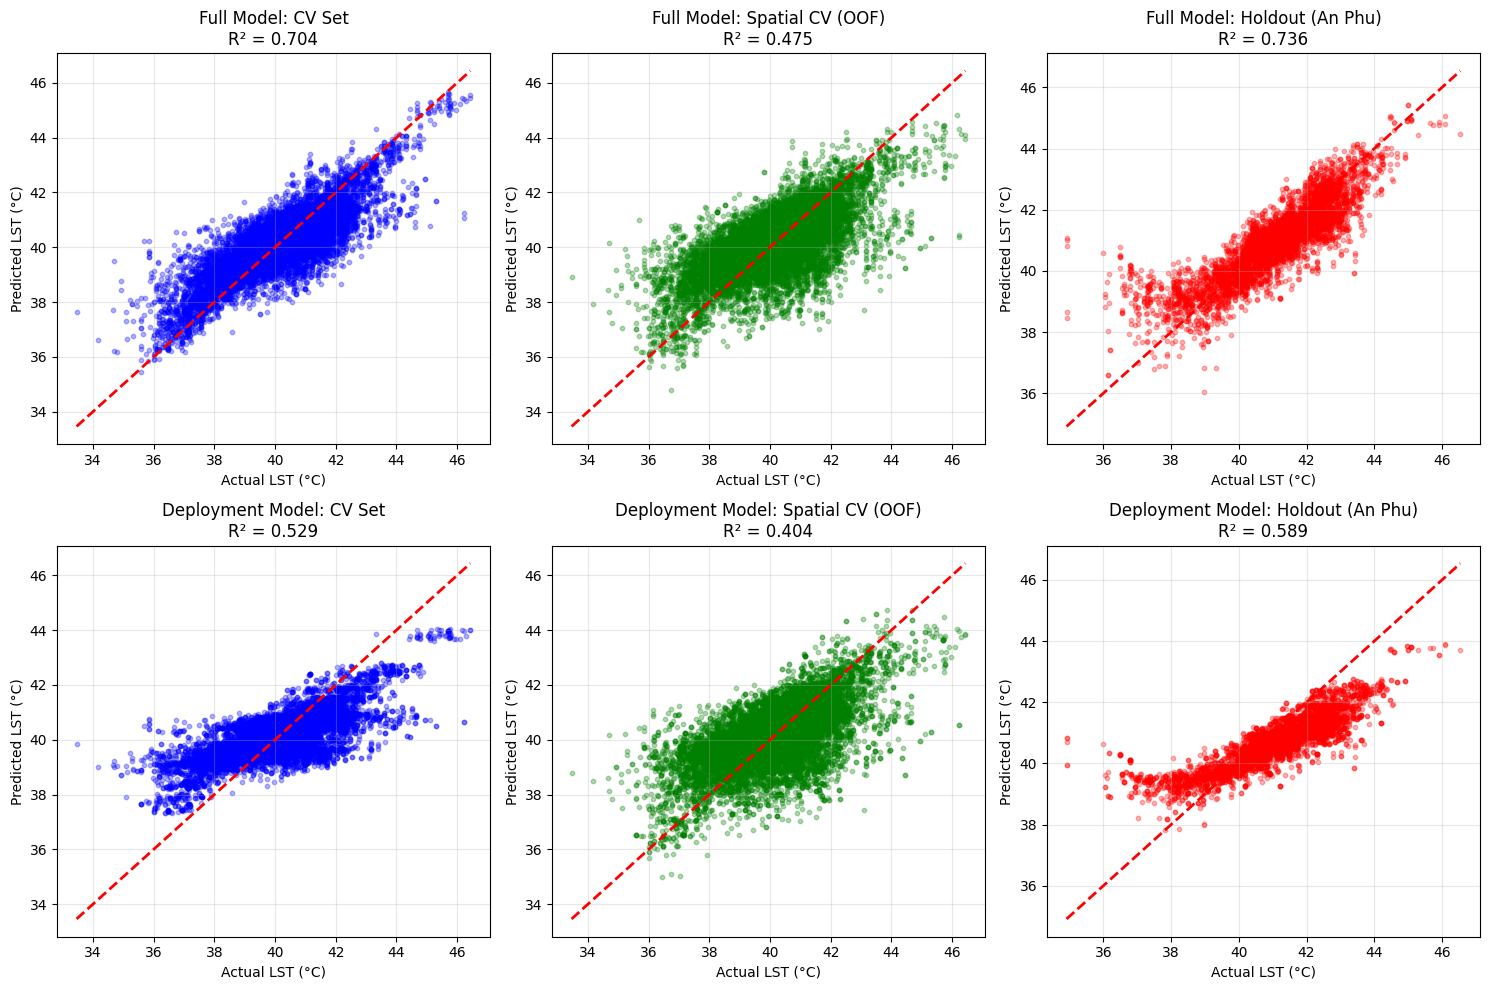

In [22]:
# Actual vs Predicted (Training, CV, Holdout).
fig, axes = plt.subplots(2, 3, figsize = (15, 10))

# Full model, Training.
axes[0, 0].scatter(y_cv, y_pred_train_full, alpha = 0.3, s = 10, c = "blue")
axes[0, 0].plot([y_cv.min(), y_cv.max()], [y_cv.min(), y_cv.max()], "r--", lw = 2)
axes[0, 0].set_xlabel("Actual LST (°C)")
axes[0, 0].set_ylabel("Predicted LST (°C)")
axes[0, 0].set_title(f"Full Model: CV Set\nR² = {train_r2_full:.3f}")
axes[0, 0].grid(alpha = 0.3)

# Full model, Spatial CV (out-of-fold).
valid_oof = ~np.isnan(cv_results_full["oof_predictions"])
axes[0, 1].scatter(
    cv_results_full["oof_actuals"][valid_oof],
    cv_results_full["oof_predictions"][valid_oof],
    alpha = 0.3, s = 10, c = "green"
)
axes[0, 1].plot([y_cv.min(), y_cv.max()], [y_cv.min(), y_cv.max()], "r--", lw = 2)
axes[0, 1].set_xlabel("Actual LST (°C)")
axes[0, 1].set_ylabel("Predicted LST (°C)")
axes[0, 1].set_title(f"Full Model: Spatial CV (OOF)\nR² = {cv_results_full['oof_r2']:.3f}")
axes[0, 1].grid(alpha = 0.3)

# Full model, Holdout.
axes[0, 2].scatter(y_holdout, y_pred_holdout_full, alpha = 0.3, s = 10, c = "red")
axes[0, 2].plot([y_holdout.min(), y_holdout.max()], [y_holdout.min(), y_holdout.max()], "r--", lw = 2)
axes[0, 2].set_xlabel("Actual LST (°C)")
axes[0, 2].set_ylabel("Predicted LST (°C)")
axes[0, 2].set_title(f"Full Model: Holdout ({HOLDOUT_WARD})\nR² = {holdout_r2_full:.3f}")
axes[0, 2].grid(alpha = 0.3)

# Deployment model, Training.
axes[1, 0].scatter(y_cv, y_pred_train_deploy, alpha = 0.3, s = 10, c = "blue")
axes[1, 0].plot([y_cv.min(), y_cv.max()], [y_cv.min(), y_cv.max()], "r--", lw = 2)
axes[1, 0].set_xlabel("Actual LST (°C)")
axes[1, 0].set_ylabel("Predicted LST (°C)")
axes[1, 0].set_title(f"Deployment Model: CV Set\nR² = {train_r2_deploy:.3f}")
axes[1, 0].grid(alpha = 0.3)

# Deployment model, Spatial CV (out-of-fold).
valid_oof_deploy = ~np.isnan(cv_results_deploy["oof_predictions"])
axes[1, 1].scatter(
    cv_results_deploy["oof_actuals"][valid_oof_deploy],
    cv_results_deploy["oof_predictions"][valid_oof_deploy],
    alpha = 0.3, s = 10, c = "green"
)
axes[1, 1].plot([y_cv.min(), y_cv.max()], [y_cv.min(), y_cv.max()], "r--", lw = 2)
axes[1, 1].set_xlabel("Actual LST (°C)")
axes[1, 1].set_ylabel("Predicted LST (°C)")
axes[1, 1].set_title(f"Deployment Model: Spatial CV (OOF)\nR² = {cv_results_deploy['oof_r2']:.3f}")
axes[1, 1].grid(alpha = 0.3)

# Deployment model, Holdout.
axes[1, 2].scatter(y_holdout, y_pred_holdout_deploy, alpha = 0.3, s = 10, c = "red")
axes[1, 2].plot([y_holdout.min(), y_holdout.max()], [y_holdout.min(), y_holdout.max()], "r--", lw = 2)
axes[1, 2].set_xlabel("Actual LST (°C)")
axes[1, 2].set_ylabel("Predicted LST (°C)")
axes[1, 2].set_title(f"Deployment Model: Holdout ({HOLDOUT_WARD})\nR² = {holdout_r2_deploy:.3f}")
axes[1, 2].grid(alpha = 0.3)

plt.tight_layout()
plt.savefig(DIAGNOSTICS_DIR / "actual_vs_predicted.png", dpi = 300, bbox_inches = "tight")
plt.show()

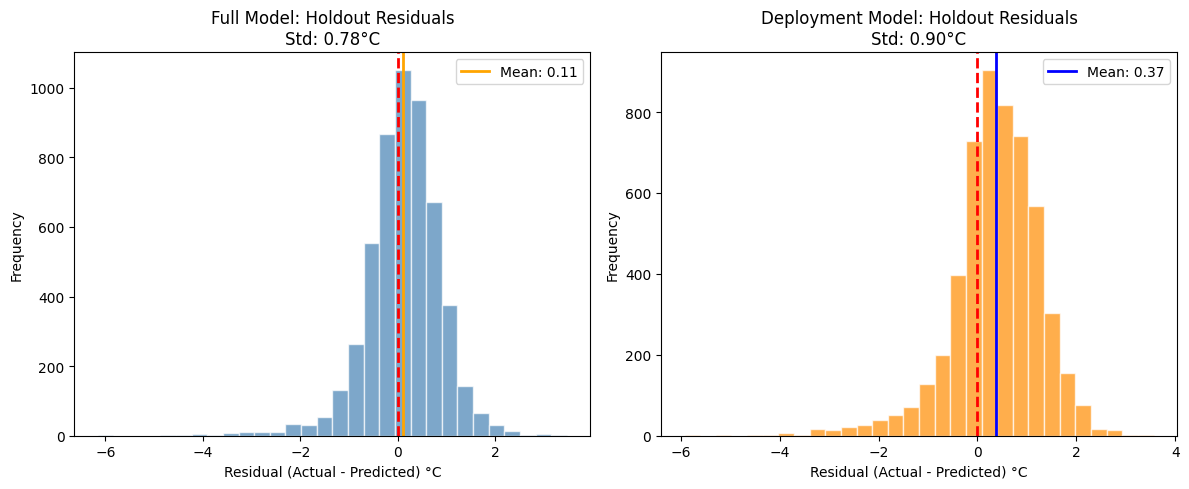

In [23]:
# Residual distributions.
fig, axes = plt.subplots(1, 2, figsize = (12, 5))

# Full model residuals.
residuals_full = y_holdout - y_pred_holdout_full
axes[0].hist(residuals_full, bins = 30, color = "steelblue", edgecolor = "white", alpha = 0.7)
axes[0].axvline(0, color = "red", linestyle = "--", lw = 2)
axes[0].axvline(residuals_full.mean(), color = "orange", linestyle = "-", lw = 2, label = f"Mean: {residuals_full.mean():.2f}")
axes[0].set_xlabel("Residual (Actual - Predicted) °C")
axes[0].set_ylabel("Frequency")
axes[0].set_title(f"Full Model: Holdout Residuals\nStd: {residuals_full.std():.2f}°C")
axes[0].legend()

# Deployment model residuals.
residuals_deploy = y_holdout - y_pred_holdout_deploy
axes[1].hist(residuals_deploy, bins = 30, color = "darkorange", edgecolor = "white", alpha = 0.7)
axes[1].axvline(0, color = "red", linestyle = "--", lw = 2)
axes[1].axvline(residuals_deploy.mean(), color = "blue", linestyle = "-", lw = 2, label = f"Mean: {residuals_deploy.mean():.2f}")
axes[1].set_xlabel("Residual (Actual - Predicted) °C")
axes[1].set_ylabel("Frequency")
axes[1].set_title(f"Deployment Model: Holdout Residuals\nStd: {residuals_deploy.std():.2f}°C")
axes[1].legend()

plt.tight_layout()
plt.savefig(DIAGNOSTICS_DIR / "residual_distributions.png", dpi = 300, bbox_inches = "tight")
plt.show()

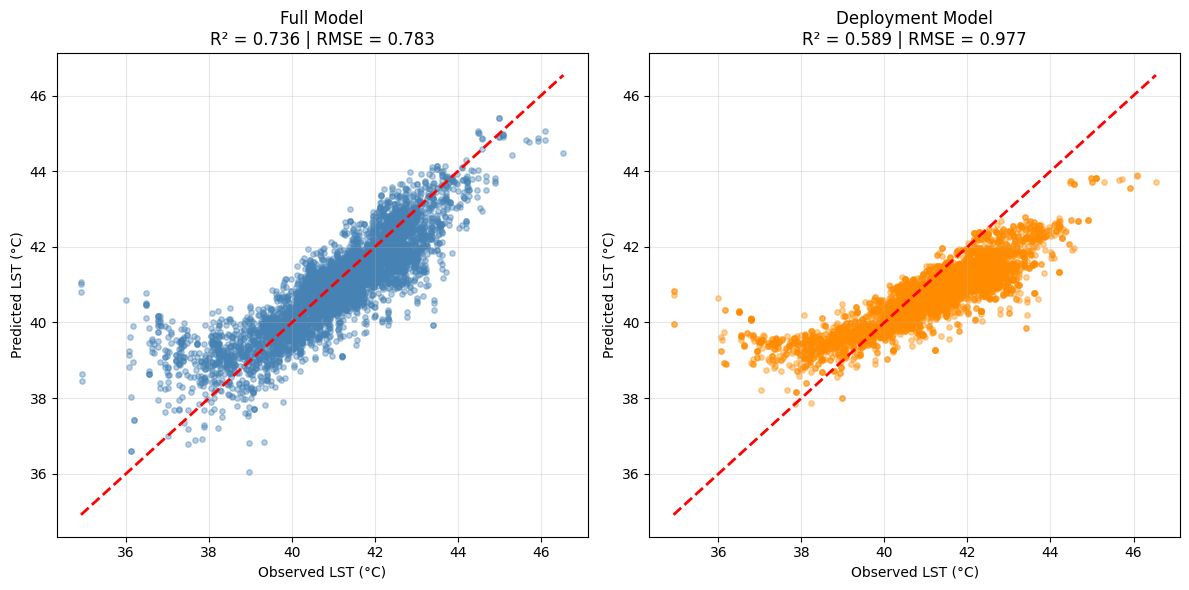

In [24]:
# Side-by-side plot for Full vs Deployment Model on Holdout Set
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Full Model (Left)
axes[0].scatter(y_holdout, y_pred_holdout_full, alpha=0.4, color='steelblue', s=15)
axes[0].plot([y_holdout.min(), y_holdout.max()], [y_holdout.min(), y_holdout.max()], 'r--', lw=2)
axes[0].set_xlabel('Observed LST (\u00b0C)')
axes[0].set_ylabel('Predicted LST (\u00b0C)')
axes[0].set_title(f'Full Model\nR\u00b2 = {holdout_r2_full:.3f} | RMSE = {holdout_rmse_full:.3f}')
axes[0].grid(alpha=0.3)

# Deployment Model (Right)
axes[1].scatter(y_holdout, y_pred_holdout_deploy, alpha=0.4, color='darkorange', s=15)
axes[1].plot([y_holdout.min(), y_holdout.max()], [y_holdout.min(), y_holdout.max()], 'r--', lw=2)
axes[1].set_xlabel('Observed LST (\u00b0C)')
axes[1].set_ylabel('Predicted LST (\u00b0C)')
axes[1].set_title(f'Deployment Model\nR\u00b2 = {holdout_r2_deploy:.3f} | RMSE = {holdout_rmse_deploy:.3f}')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(DIAGNOSTICS_DIR / "model_predictions_vs_observations.png", dpi = 300, bbox_inches = "tight")
plt.show()

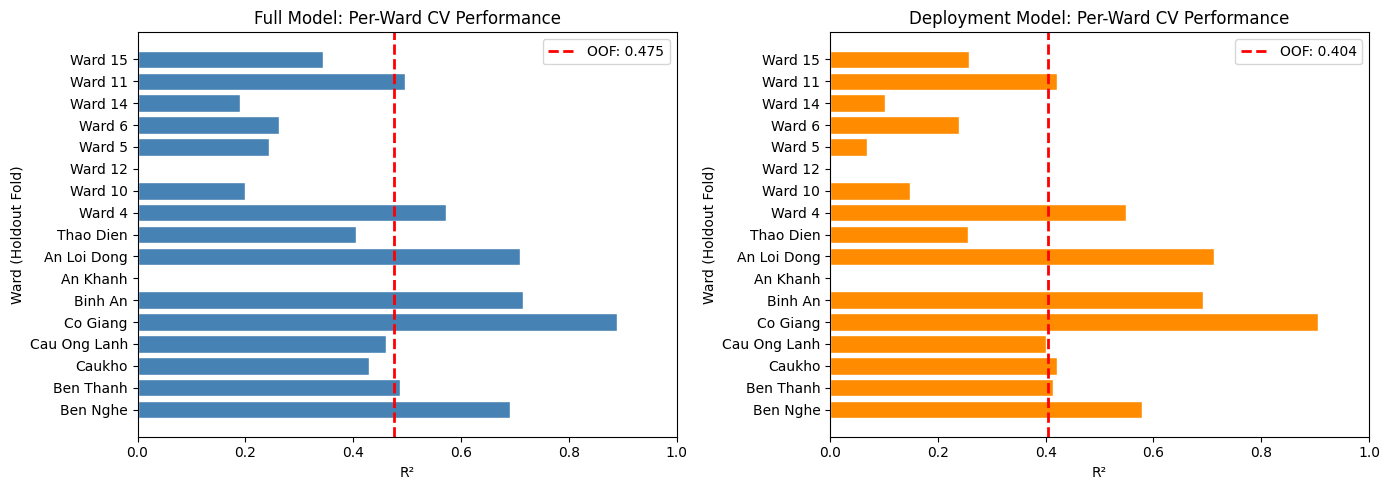

In [25]:
# Per-ward CV performance.
fig, axes = plt.subplots(1, 2, figsize = (14, 5))

# Full model per-ward R2.
ward_r2_full = pd.DataFrame(cv_results_full["fold_metrics"])
axes[0].barh(ward_r2_full["group"], ward_r2_full["r2"], color = "steelblue", edgecolor = "white")
axes[0].axvline(cv_results_full["oof_r2"], color = "red", linestyle = "--", lw = 2, label = f"OOF: {cv_results_full['oof_r2']:.3f}")
axes[0].set_xlabel("R²")
axes[0].set_ylabel("Ward (Holdout Fold)")
axes[0].set_title("Full Model: Per-Ward CV Performance")
axes[0].legend()
axes[0].set_xlim(0, 1)

# Deployment model per-ward R2.
ward_r2_deploy = pd.DataFrame(cv_results_deploy["fold_metrics"])
axes[1].barh(ward_r2_deploy["group"], ward_r2_deploy["r2"], color = "darkorange", edgecolor = "white")
axes[1].axvline(cv_results_deploy["oof_r2"], color = "red", linestyle = "--", lw = 2, label = f"OOF: {cv_results_deploy['oof_r2']:.3f}")
axes[1].set_xlabel("R²")
axes[1].set_ylabel("Ward (Holdout Fold)")
axes[1].set_title("Deployment Model: Per-Ward CV Performance")
axes[1].legend()
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.savefig(DIAGNOSTICS_DIR / "per_ward_cv_performance.png", dpi = 300, bbox_inches = "tight")
plt.show()

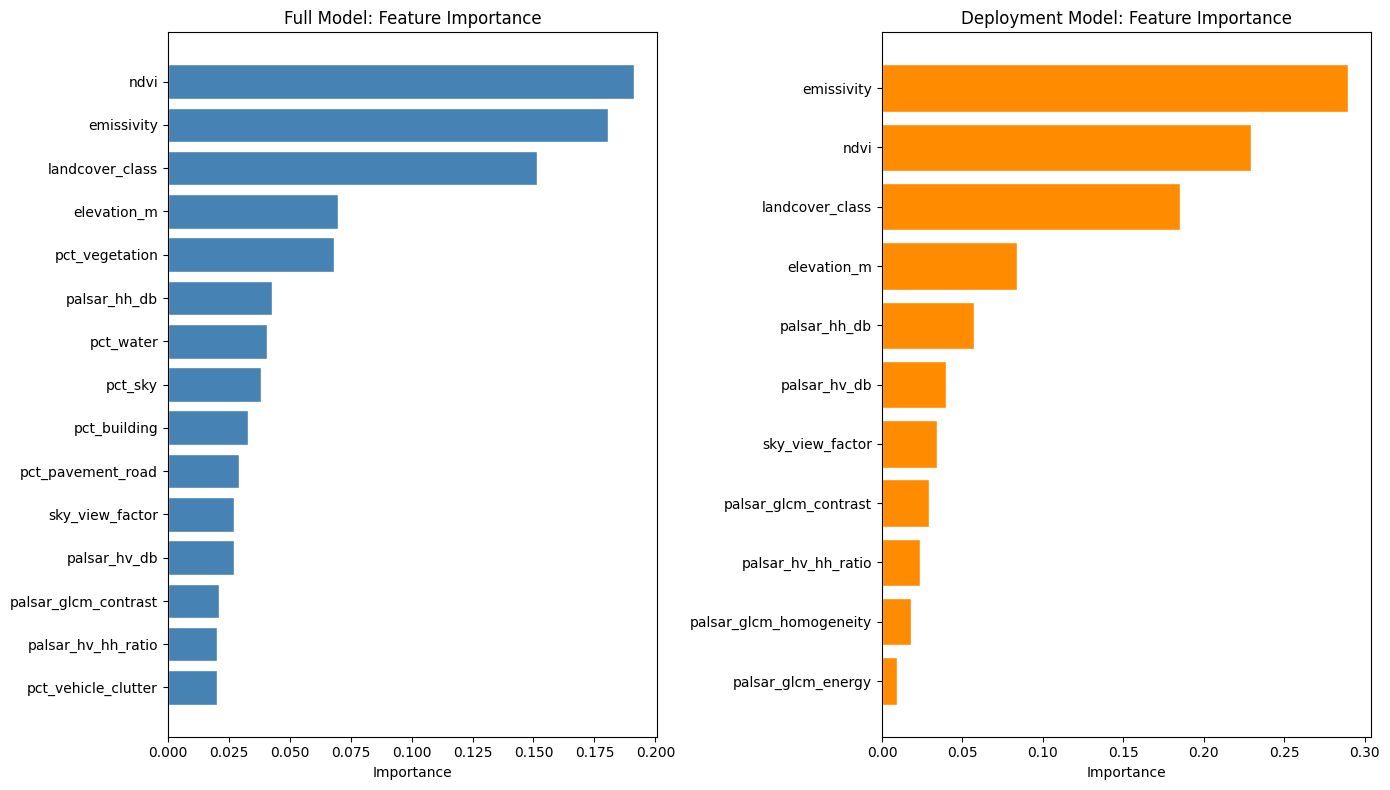

Diagnostic plots saved to: models/diagnostics


In [26]:
# Feature importance comparison.
fig, axes = plt.subplots(1, 2, figsize = (14, 8))

# Full model.
top_n = min(15, len(importance_full))
axes[0].barh(
    importance_full.head(top_n)["feature"][::-1],
    importance_full.head(top_n)["importance"][::-1],
    color = "steelblue",
    edgecolor = "white"
)
axes[0].set_xlabel("Importance")
axes[0].set_title("Full Model: Feature Importance")

# Deployment model.
axes[1].barh(
    importance_deploy["feature"][::-1],
    importance_deploy["importance"][::-1],
    color = "darkorange",
    edgecolor = "white"
)
axes[1].set_xlabel("Importance")
axes[1].set_title("Deployment Model: Feature Importance")

plt.tight_layout()
plt.savefig(DIAGNOSTICS_DIR / "feature_importance.png", dpi = 300, bbox_inches = "tight")
plt.show()

print(f"Diagnostic plots saved to: {DIAGNOSTICS_DIR}")

## SHAP ANALYSIS

SHAP (SHapley Additive exPlanations) decomposes each prediction into per-feature contributions, providing both global importance rankings and directional effects that standard feature importance cannot capture.

In [27]:
!pip install shap -q

In [28]:
import shap

print(f"SHAP version: {shap.__version__}")

SHAP version: 0.51.0


In [29]:
# Compute SHAP values for both models on the holdout set.
# TreeExplainer is exact for tree-based models.

# Full model SHAP.
explainer_full = shap.TreeExplainer(model_full)
shap_values_full = explainer_full.shap_values(df_holdout[ALL_FEATURES])

print(f"Full model SHAP values shape: {shap_values_full.shape}")

# Deployment model SHAP.
explainer_deploy = shap.TreeExplainer(model_deploy)
shap_values_deploy = explainer_deploy.shap_values(df_holdout[SHARED_FEATURES])

print(f"Deployment model SHAP values shape: {shap_values_deploy.shape}")

Full model SHAP values shape: (5313, 18)
Deployment model SHAP values shape: (5313, 11)


### SHAP BEESWARM PLOTS

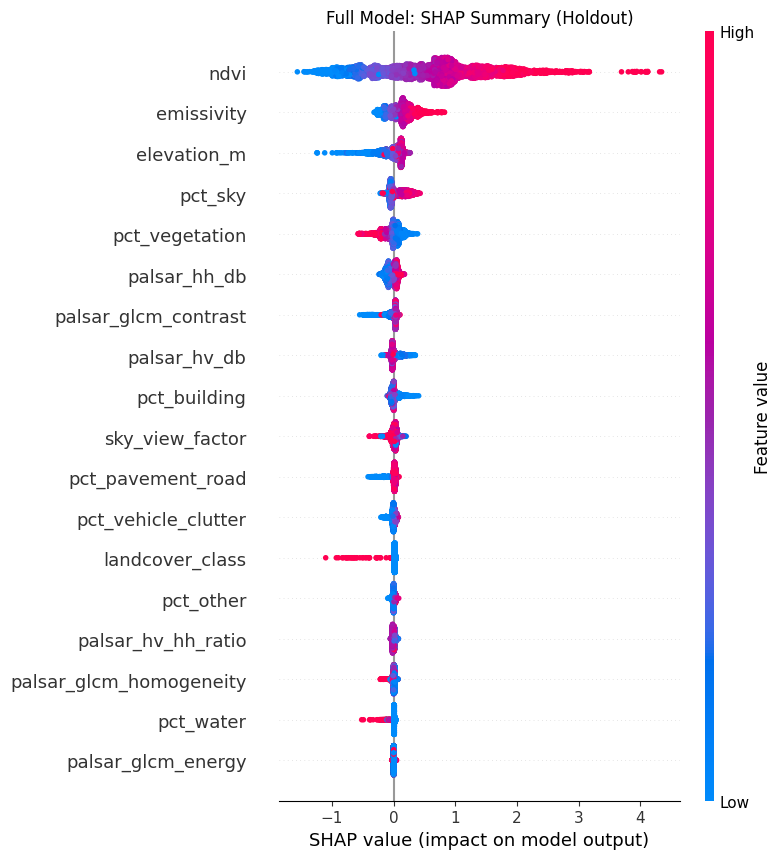

In [30]:
# Full model beeswarm.
fig, ax = plt.subplots(figsize = (10, 8))
shap.summary_plot(
    shap_values_full,
    df_holdout[ALL_FEATURES],
    show = False,
    max_display = 18
)
plt.title("Full Model: SHAP Summary (Holdout)")
plt.tight_layout()
plt.savefig(DIAGNOSTICS_DIR / "shap_beeswarm_full.png", dpi = 300, bbox_inches = "tight")
plt.show()

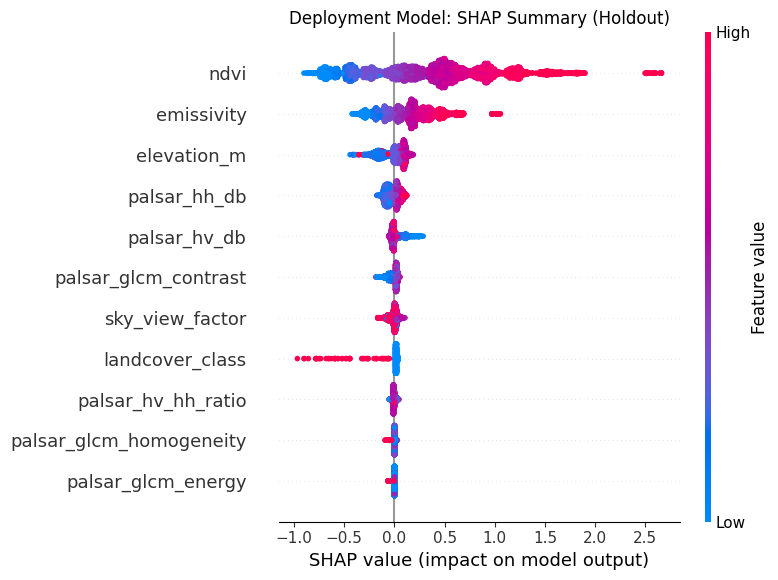

In [31]:
# Deployment model beeswarm.
fig, ax = plt.subplots(figsize = (10, 6))
shap.summary_plot(
    shap_values_deploy,
    df_holdout[SHARED_FEATURES],
    show = False,
    max_display = 11
)
plt.title("Deployment Model: SHAP Summary (Holdout)")
plt.tight_layout()
plt.savefig(DIAGNOSTICS_DIR / "shap_beeswarm_deploy.png", dpi = 300, bbox_inches = "tight")
plt.show()

### SHAP DEPENDENCE PLOTS (TOP 3 DEPLOYMENT FEATURES)

Top 3 deployment features: ['emissivity', 'ndvi', 'landcover_class']


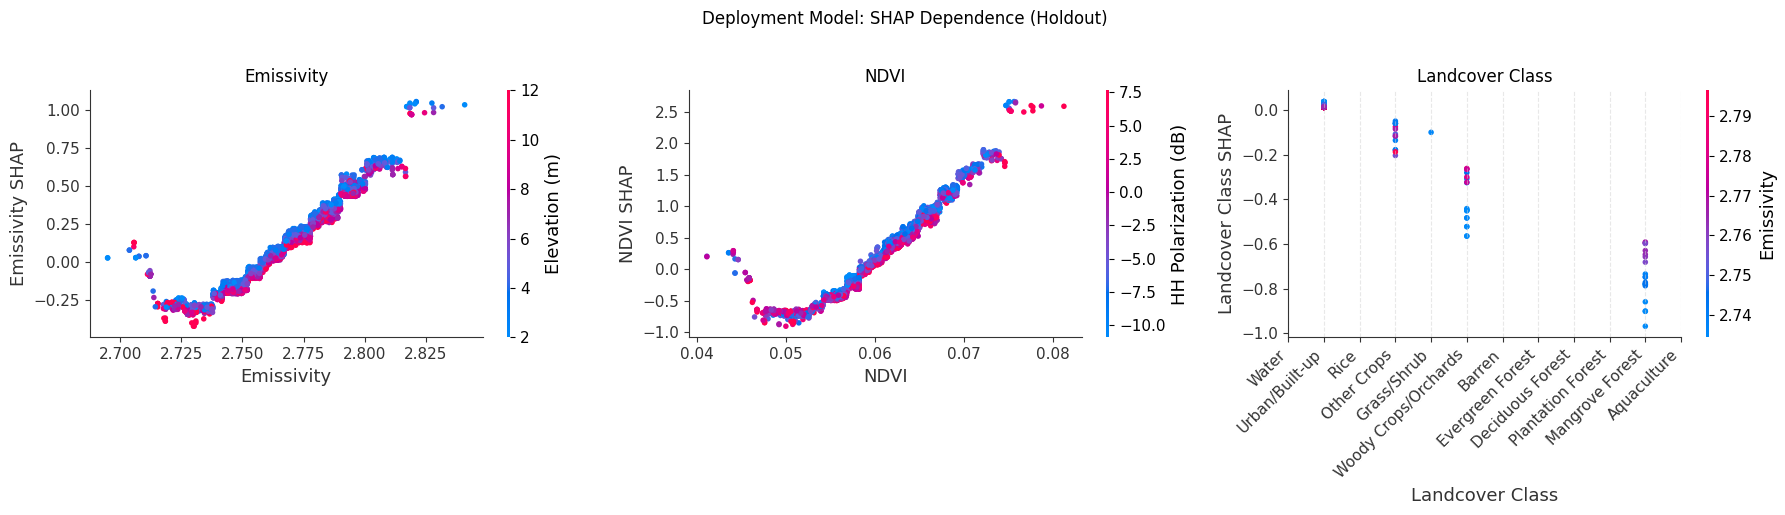

In [32]:
# Identify top 3 features by importance from deployment model.
top3_features = importance_deploy.head(3)["feature"].tolist()
print(f"Top 3 deployment features: {top3_features}")

# Mapping for display labels
label_map = {
    "emissivity": "Emissivity",
    "ndvi": "NDVI",
    "landcover_class": "Landcover Class",
    "elevation_m": "Elevation (m)",
    "palsar_hh_db": "HH Polarization (dB)"
}

# Mapping for landcover axis ticks
landcover_labels = {
    1.0: "Water",
    2.0: "Urban/Built-up",
    3.0: "Rice",
    4.0: "Other Crops",
    5.0: "Grass/Shrub",
    6.0: "Woody Crops/Orchards",
    7.0: "Barren",
    8.0: "Evergreen Forest",
    9.0: "Deciduous Forest",
    10.0: "Plantation Forest",
    11.0: "Mangrove Forest",
    12.0: "Aquaculture"
}

fig, axes = plt.subplots(1, 3, figsize = (18, 5))

for i, feat in enumerate(top3_features):
    display_name = label_map.get(feat, feat)

    # Rename columns in a temporary dataframe so the color bar uses display names
    df_plot = df_holdout[SHARED_FEATURES].rename(columns = label_map)

    shap.dependence_plot(
        display_name,
        shap_values_deploy,
        df_plot,
        ax = axes[i],
        show = False
    )

    # Apply requested titles and labels
    axes[i].set_title(display_name)
    axes[i].set_xlabel(display_name)
    axes[i].set_ylabel(f"{display_name} SHAP")

    # If the feature is landcover_class, apply categorical tick labels and vertical grid
    if feat == "landcover_class":
        ticks = sorted(landcover_labels.keys())
        labels = [landcover_labels[t] for t in ticks]
        axes[i].set_xticks(ticks)
        axes[i].set_xticklabels(labels, rotation = 45, ha = "right")
        # Add light vertical grid
        axes[i].grid(True, axis = "x", linestyle = "--", alpha = 0.5, color = "lightgray")

plt.suptitle("Deployment Model: SHAP Dependence (Holdout)", y = 1.02)
plt.tight_layout()
plt.savefig(DIAGNOSTICS_DIR / "shap_dependence_top3_deployment.png", dpi = 300, bbox_inches = "tight")
plt.show()

Top 3 full model features: ['ndvi', 'emissivity', 'landcover_class']


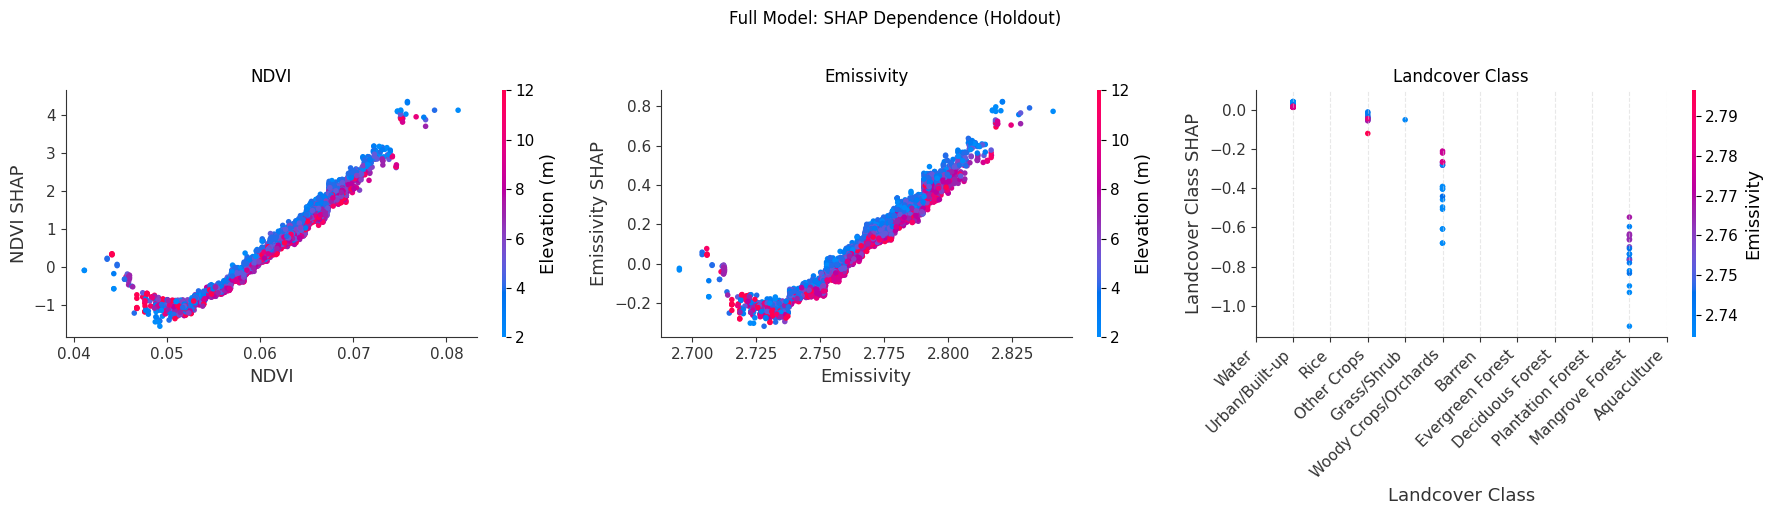

In [33]:
# Identify top 3 features by importance from full model.
top3_features_full = importance_full.head(3)["feature"].tolist()
print(f"Top 3 full model features: {top3_features_full}")

# Mapping for display labels
label_map = {
    "emissivity": "Emissivity",
    "ndvi": "NDVI",
    "landcover_class": "Landcover Class",
    "elevation_m": "Elevation (m)",
    "palsar_hh_db": "HH Polarization (dB)"
}

# Mapping for landcover axis ticks
landcover_labels = {
    1.0: "Water",
    2.0: "Urban/Built-up",
    3.0: "Rice",
    4.0: "Other Crops",
    5.0: "Grass/Shrub",
    6.0: "Woody Crops/Orchards",
    7.0: "Barren",
    8.0: "Evergreen Forest",
    9.0: "Deciduous Forest",
    10.0: "Plantation Forest",
    11.0: "Mangrove Forest",
    12.0: "Aquaculture"
}

fig, axes = plt.subplots(1, 3, figsize = (18, 5))

for i, feat in enumerate(top3_features_full):
    display_name = label_map.get(feat, feat)

    # Rename columns in temporary dataframe so the color bar uses display names
    df_plot = df_holdout[ALL_FEATURES].rename(columns = label_map)

    shap.dependence_plot(
        display_name,
        shap_values_full,
        df_plot,
        ax = axes[i],
        show = False
    )

    # Apply requested labels
    axes[i].set_title(display_name)
    axes[i].set_xlabel(display_name)
    axes[i].set_ylabel(f"{display_name} SHAP")

    # If the feature is landcover_class, apply categorical tick labels and grid
    if feat == "landcover_class":
        ticks = sorted(landcover_labels.keys())
        labels = [landcover_labels[t] for t in ticks]
        axes[i].set_xticks(ticks)
        axes[i].set_xticklabels(labels, rotation = 45, ha = "right")
        # Add light vertical grid
        axes[i].grid(True, axis = "x", linestyle = "--", alpha = 0.5, color = "lightgray")

plt.suptitle("Full Model: SHAP Dependence (Holdout)", y = 1.02)
plt.tight_layout()
plt.savefig(DIAGNOSTICS_DIR / "shap_dependence_top3_full.png", dpi = 300, bbox_inches = "tight")
plt.show()

### PER-WARD MEAN SHAP ANALYSIS

Decompose the mean absolute SHAP contribution per ward. Wards where the model struggles may show different feature contribution profiles, revealing why spatial generalization is uneven.

In [34]:
# Compute per-ward mean absolute SHAP for deployment model.
# Use CV OOF predictions to cover all CV wards.
explainer_cv = shap.TreeExplainer(model_deploy)
shap_values_cv = explainer_cv.shap_values(X_cv[SHARED_FEATURES])

# Build DataFrame of absolute SHAP values with ward labels.
shap_df = pd.DataFrame(
    np.abs(shap_values_cv),
    columns = SHARED_FEATURES,
    index = X_cv.index
)
shap_df["ward"] = groups_cv.values

# Mean absolute SHAP per ward.
ward_shap = shap_df.groupby("ward")[SHARED_FEATURES].mean()

print("MEAN ABSOLUTE SHAP BY WARD (DEPLOYMENT MODEL)")
print(ward_shap.round(4).to_string())
print("")

# Merge with per-ward CV R2 for context.
fold_df = pd.DataFrame(cv_results_deploy["fold_metrics"])
ward_r2_map = dict(zip(fold_df["group"], fold_df["r2"]))

print("Per-ward CV R2 alongside dominant SHAP feature:")
for ward_name in ward_shap.index:
    dominant = ward_shap.loc[ward_name].idxmax()
    dominant_val = ward_shap.loc[ward_name].max()
    r2_val = ward_r2_map.get(ward_name, float("nan"))
    print(f"  {ward_name:20s}: R2 = {r2_val:6.3f}, dominant feature = {dominant} ({dominant_val:.4f})")

MEAN ABSOLUTE SHAP BY WARD (DEPLOYMENT MODEL)
                ndvi  emissivity  palsar_hh_db  palsar_hv_db  palsar_hv_hh_ratio  palsar_glcm_contrast  palsar_glcm_homogeneity  palsar_glcm_energy  elevation_m  sky_view_factor  landcover_class
ward                                                                                                                                                                                              
An Khanh      0.4289      0.1655        0.0765        0.0785              0.0110                0.0270                   0.0041              0.0005       0.1286           0.0384           0.0643
An Loi Dong   0.5543      0.2197        0.0470        0.0398              0.0065                0.0317                   0.0068              0.0009       0.1371           0.0352           0.0512
Ben Nghe      0.4930      0.1966        0.0596        0.0261              0.0088                0.0149                   0.0075              0.0007       0.1082           0.0

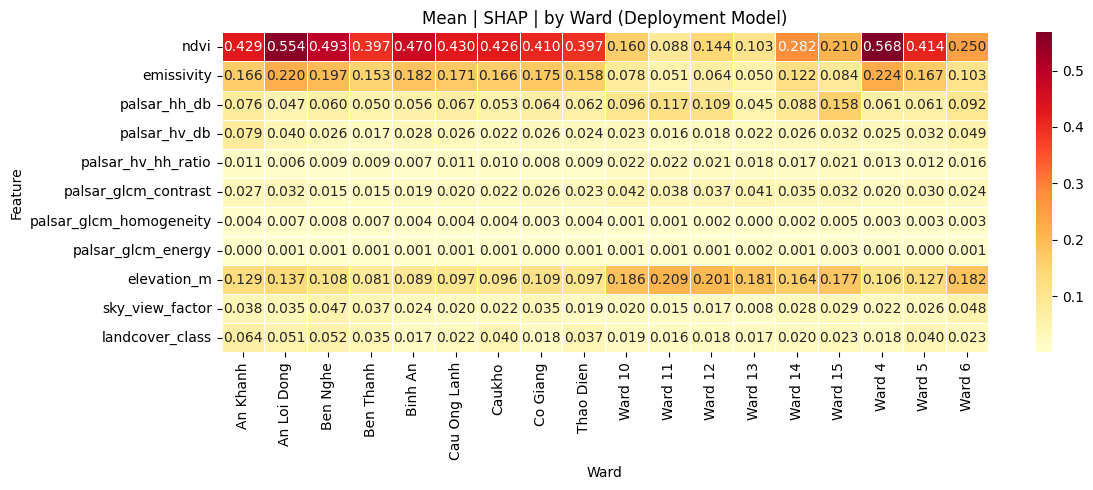

In [35]:
# Heatmap of per-ward SHAP contributions.
fig, ax = plt.subplots(figsize = (12, 5))

sns.heatmap(
    ward_shap.T,
    annot = True,
    fmt = ".3f",
    cmap = "YlOrRd",
    ax = ax,
    linewidths = 0.5
)
ax.set_title("Mean | SHAP | by Ward (Deployment Model)")
ax.set_ylabel("Feature")
ax.set_xlabel("Ward")

plt.tight_layout()
plt.savefig(DIAGNOSTICS_DIR / "shap_per_ward_heatmap_deployment.png", dpi = 300, bbox_inches = "tight")
plt.show()

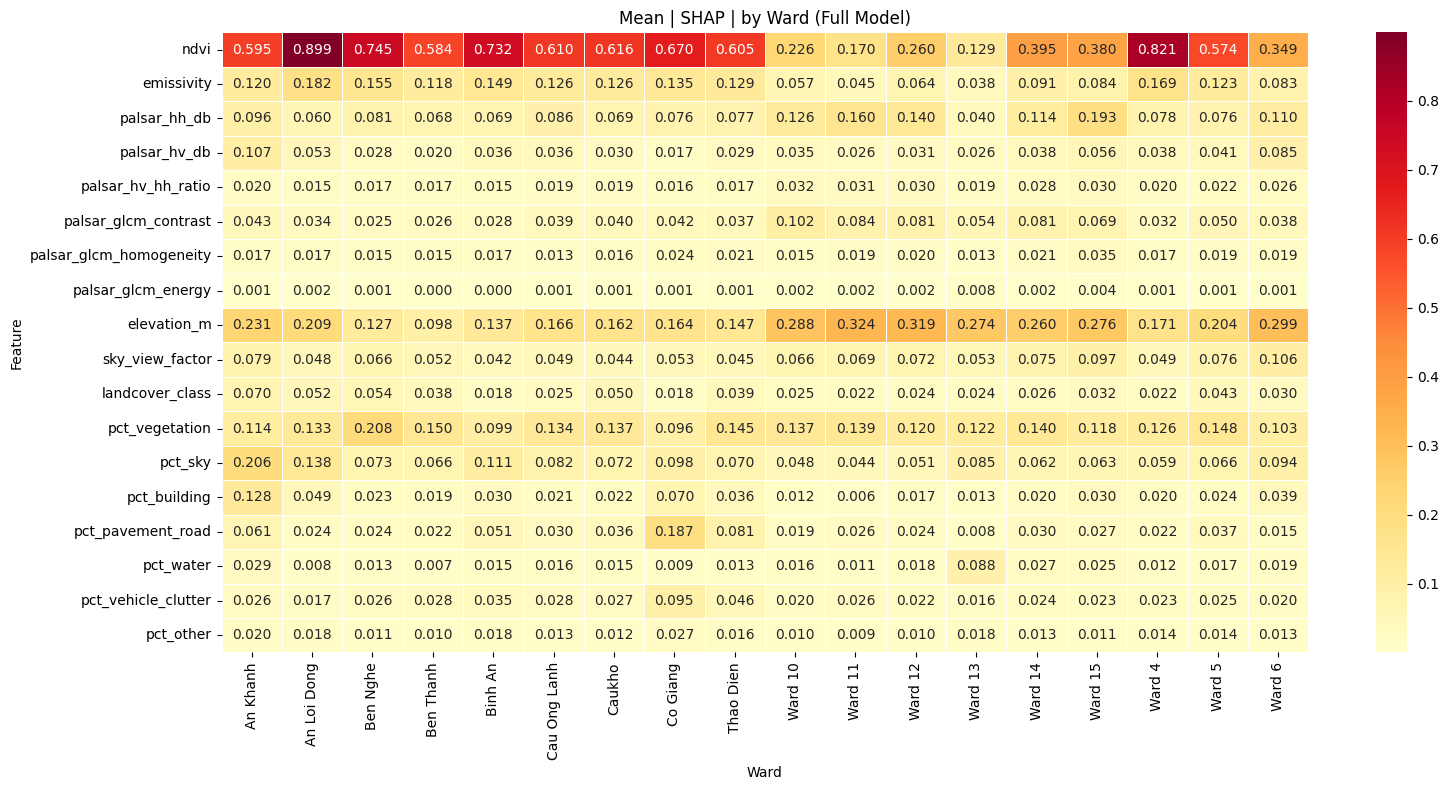

In [36]:
# Compute per-ward mean absolute SHAP for full model.
explainer_cv_full = shap.TreeExplainer(model_full)
shap_values_cv_full = explainer_cv_full.shap_values(X_cv[ALL_FEATURES])

# Build DataFrame of absolute SHAP values with ward labels.
shap_df_full = pd.DataFrame(
    np.abs(shap_values_cv_full),
    columns = ALL_FEATURES,
    index = X_cv.index
)
shap_df_full["ward"] = groups_cv.values

# Mean absolute SHAP per ward.
ward_shap_full = shap_df_full.groupby("ward")[ALL_FEATURES].mean()

# Heatmap of per-ward SHAP contributions for the full model.
fig, ax = plt.subplots(figsize = (16, 8))

sns.heatmap(
    ward_shap_full.T,
    annot = True,
    fmt = ".3f",
    cmap = "YlOrRd",
    ax = ax,
    linewidths = 0.5
)
ax.set_title("Mean | SHAP | by Ward (Full Model)")
ax.set_ylabel("Feature")
ax.set_xlabel("Ward")

plt.tight_layout()
plt.savefig(DIAGNOSTICS_DIR / "shap_per_ward_heatmap_full.png", dpi = 300, bbox_inches = "tight")
plt.show()

## BASELINE MODEL COMPARISON

Compare XGBoost against two simple baselines to contextualize model skill:
- **Spatial mean baseline:** Predict each point as the mean LST of its ward (from training data). This is the floor that any spatial model should beat.
- **Linear regression on top 3 features:** `landcover_class`, `emissivity`, `ndvi` (the deployment model's top 3 by importance). If XGBoost only marginally beats a linear model on these features, the nonlinear interactions may not justify the complexity.

In [37]:
from sklearn.linear_model import LinearRegression

# Define top 3 features for the linear baseline.
TOP3 = importance_deploy.head(3)["feature"].tolist()
print(f"Linear baseline features: {TOP3}")

Linear baseline features: ['emissivity', 'ndvi', 'landcover_class']


In [38]:
# BASELINE 1: Spatial mean (predict ward-average LST from training data).
# Compute per-ward mean LST from the CV training set.
ward_means = df_cv.groupby("spatial_group")[TARGET].mean()

# Predict holdout using the ward mean (holdout ward must appear in training wards
# via the buffered boundary overlap, or fall back to global mean).
holdout_ward_label = df_holdout["spatial_group"].iloc[0]
global_mean = df_cv[TARGET].mean()

if holdout_ward_label in ward_means.index:
    spatial_mean_pred = np.full(len(y_holdout), ward_means[holdout_ward_label])
    print(f"Spatial mean for {holdout_ward_label}: {ward_means[holdout_ward_label]:.2f} C.")
else:
    spatial_mean_pred = np.full(len(y_holdout), global_mean)
    print(f"Ward {holdout_ward_label} not in training set. Using global mean: {global_mean:.2f} C.")

baseline_spatial_r2 = r2_score(y_holdout, spatial_mean_pred)
baseline_spatial_rmse = np.sqrt(mean_squared_error(y_holdout, spatial_mean_pred))

print(f"Spatial Mean Baseline: Holdout R2 = {baseline_spatial_r2:.4f}, RMSE = {baseline_spatial_rmse:.4f}.")

Ward An Phu not in training set. Using global mean: 40.23 C.
Spatial Mean Baseline: Holdout R2 = -0.3172, RMSE = 1.7491.


In [39]:
# BASELINE 2: Linear regression on top 3 features.
lr_model = LinearRegression()
lr_model.fit(df_cv_train[TOP3], df_cv_train[TARGET])

# Holdout performance.
lr_pred_holdout = lr_model.predict(df_holdout[TOP3])
baseline_lr_r2 = r2_score(y_holdout, lr_pred_holdout)
baseline_lr_rmse = np.sqrt(mean_squared_error(y_holdout, lr_pred_holdout))

print(f"Linear Regression (top 3): Holdout R2 = {baseline_lr_r2:.4f}, RMSE = {baseline_lr_rmse:.4f}.")
print(f"Coefficients: {dict(zip(TOP3, lr_model.coef_.round(4)))}")
print(f"Intercept: {lr_model.intercept_:.4f}")

Linear Regression (top 3): Holdout R2 = -0.1179, RMSE = 1.6114.
Coefficients: {'emissivity': np.float64(440788.8972), 'ndvi': np.float64(-1602856.3593), 'landcover_class': np.float64(-0.3715)}
Intercept: -1121967.6209


In [40]:
# Comparison table.
baseline_df = pd.DataFrame({
    "Model": [
        "Spatial Mean (ward avg)",
        f"Linear Regression ({len(TOP3)} features)",
        f"XGBoost Deployment ({len(SHARED_FEATURES)} features)",
        f"XGBoost Full ({len(ALL_FEATURES)} features)"
    ],
    "Holdout R2": [
        f"{baseline_spatial_r2:.4f}",
        f"{baseline_lr_r2:.4f}",
        f"{holdout_r2_deploy:.4f}",
        f"{holdout_r2_full:.4f}"
    ],
    "Holdout RMSE": [
        f"{baseline_spatial_rmse:.4f}",
        f"{baseline_lr_rmse:.4f}",
        f"{holdout_rmse_deploy:.4f}",
        f"{holdout_rmse_full:.4f}"
    ]
})

print("BASELINE MODEL COMPARISON")
print(baseline_df.to_string(index = False))

BASELINE MODEL COMPARISON
                           Model Holdout R2 Holdout RMSE
         Spatial Mean (ward avg)    -0.3172       1.7491
  Linear Regression (3 features)    -0.1179       1.6114
XGBoost Deployment (11 features)     0.5888       0.9773
      XGBoost Full (18 features)     0.7362       0.7828


## FEATURE ABLATION STUDY

Quantify the marginal value of feature groups by comparing three nested subsets:
- **Top 3 only** (3 features): `landcover_class`, `emissivity`, `ndvi` — 71.6% of deployment importance.
- **Top 3 + PALSAR** (9 features): Add all 6 radar features to capture urban structure and texture.
- **Full deployment** (11 features): All raster features including DSM elevation and sky view factor.

Each variant runs through the same spatial CV and holdout evaluation pipeline.

In [41]:
# Define ablation feature sets.
ABLATION_TOP3 = importance_deploy.head(3)["feature"].tolist()
ABLATION_TOP3_PALSAR = ABLATION_TOP3 + PALSAR_FEATURES
ABLATION_FULL_DEPLOY = SHARED_FEATURES

ablation_configs = [
    ("Top 3 Only", ABLATION_TOP3),
    ("Top 3 + PALSAR", ABLATION_TOP3_PALSAR),
    ("Full Deployment", ABLATION_FULL_DEPLOY),
]

print("ABLATION FEATURE SETS")
for name, feats in ablation_configs:
    print(f"  {name}: {len(feats)} features -> {feats}")

ABLATION FEATURE SETS
  Top 3 Only: 3 features -> ['emissivity', 'ndvi', 'landcover_class']
  Top 3 + PALSAR: 9 features -> ['emissivity', 'ndvi', 'landcover_class', 'palsar_hh_db', 'palsar_hv_db', 'palsar_hv_hh_ratio', 'palsar_glcm_contrast', 'palsar_glcm_homogeneity', 'palsar_glcm_energy']
  Full Deployment: 11 features -> ['ndvi', 'emissivity', 'palsar_hh_db', 'palsar_hv_db', 'palsar_hv_hh_ratio', 'palsar_glcm_contrast', 'palsar_glcm_homogeneity', 'palsar_glcm_energy', 'elevation_m', 'sky_view_factor', 'landcover_class']


In [42]:
# Run spatial CV and holdout evaluation for each ablation variant.
ablation_results = []

for name, feats in ablation_configs:
    print("")

    # Spatial cross-validation.
    cv_result = spatial_cross_validation(
        X = X_cv,
        y = y_cv,
        groups = groups_cv,
        features = feats,
        params = XGB_PARAMS,
        model_name = name
    )

    # Train final model with spatial early stopping.
    ablation_model = xgb.XGBRegressor(**XGB_PARAMS)
    ablation_model.fit(
        df_cv_train[feats],
        df_cv_train[TARGET],
        eval_set = [(df_cv_es[feats], df_cv_es[TARGET])],
        verbose = False
    )

    # Holdout evaluation.
    ablation_pred = ablation_model.predict(df_holdout[feats])
    ab_holdout_r2 = r2_score(y_holdout, ablation_pred)
    ab_holdout_rmse = np.sqrt(mean_squared_error(y_holdout, ablation_pred))
    ab_holdout_mae = mean_absolute_error(y_holdout, ablation_pred)

    ablation_results.append({
        "name": name,
        "n_features": len(feats),
        "cv_oof_r2": cv_result["oof_r2"],
        "cv_avg_r2": cv_result["avg_r2"],
        "cv_oof_rmse": cv_result["oof_rmse"],
        "holdout_r2": ab_holdout_r2,
        "holdout_rmse": ab_holdout_rmse,
        "holdout_mae": ab_holdout_mae,
        "best_iteration": ablation_model.best_iteration
    })

    print(f"Holdout: R2 = {ab_holdout_r2:.4f}, RMSE = {ab_holdout_rmse:.4f}, MAE = {ab_holdout_mae:.4f}, trees = {ablation_model.best_iteration}.")


SPATIAL CROSS-VALIDATION: Top 3 Only.
Strategy: Leave-one-ward-out.
Groups: 18.
Early stopping: random 15% split WITHIN training fold (not test fold).
Fold 1/18 (Ben Nghe): RMSE = 1.0320, R2 = 0.6411, MAE = 0.7189, n = 2035, trees = 185.
Fold 2/18 (Ben Thanh): RMSE = 0.9050, R2 = 0.3678, MAE = 0.6726, n = 1835, trees = 187.
Fold 3/18 (Caukho): RMSE = 1.0127, R2 = 0.4626, MAE = 0.7541, n = 1048, trees = 171.
Fold 4/18 (Cau Ong Lanh): RMSE = 1.0986, R2 = 0.3804, MAE = 0.7761, n = 606, trees = 245.
Fold 5/18 (Co Giang): RMSE = 0.4298, R2 = 0.8676, MAE = 0.3435, n = 29, trees = 162.
Fold 6/18 (Binh An): RMSE = 0.8242, R2 = 0.6252, MAE = 0.6592, n = 633, trees = 123.
Fold 7/18 (An Khanh): RMSE = 1.6567, R2 = -0.2633, MAE = 1.3104, n = 517, trees = 151.
Fold 8/18 (An Loi Dong): RMSE = 0.9452, R2 = 0.7002, MAE = 0.7655, n = 29, trees = 108.
Fold 9/18 (Thao Dien): RMSE = 1.0449, R2 = 0.4369, MAE = 0.8281, n = 1747, trees = 128.
Fold 10/18 (Ward 4): RMSE = 1.0339, R2 = 0.5650, MAE = 0.7334, n 

In [43]:
# Ablation results table.
ablation_df = pd.DataFrame(ablation_results)

print("FEATURE ABLATION RESULTS")
print(ablation_df[["name", "n_features", "cv_oof_r2", "cv_avg_r2", "holdout_r2", "holdout_rmse"]].to_string(index = False))

# Marginal gains.
print("")
print("MARGINAL GAINS")
for i in range(1, len(ablation_results)):
    prev = ablation_results[i - 1]
    curr = ablation_results[i]
    delta_r2 = curr["holdout_r2"] - prev["holdout_r2"]
    delta_features = curr["n_features"] - prev["n_features"]
    print(f"  {prev['name']} -> {curr['name']}: +{delta_features} features, holdout R2 delta = {delta_r2:+.4f}")

FEATURE ABLATION RESULTS
           name  n_features  cv_oof_r2  cv_avg_r2  holdout_r2  holdout_rmse
     Top 3 Only           3   0.352042   0.150447    0.616119      0.944265
 Top 3 + PALSAR           9   0.367806   0.226659    0.642654      0.911044
Full Deployment          11   0.403586   0.313819    0.588826      0.977255

MARGINAL GAINS
  Top 3 Only -> Top 3 + PALSAR: +6 features, holdout R2 delta = +0.0265
  Top 3 + PALSAR -> Full Deployment: +2 features, holdout R2 delta = -0.0538


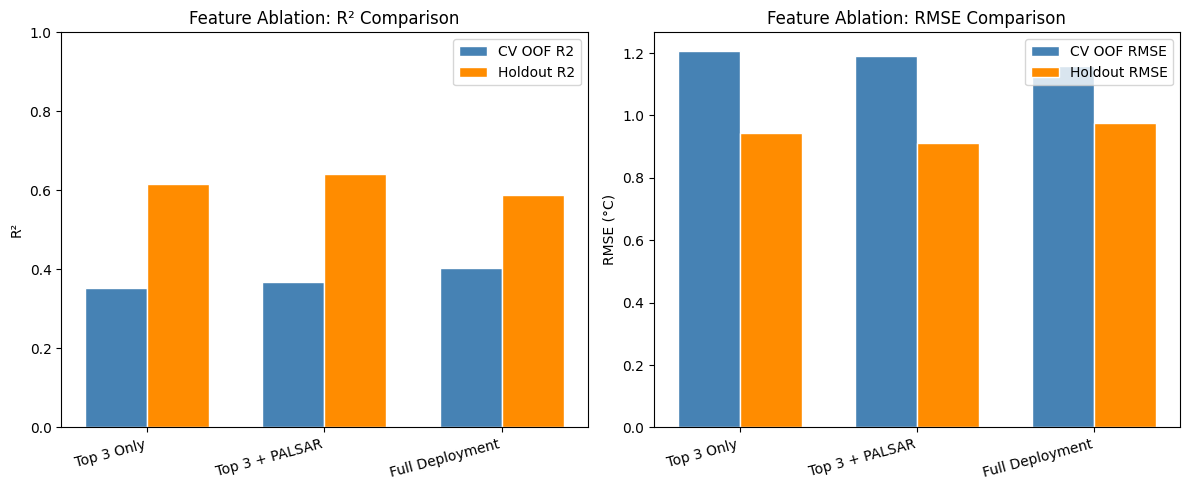

In [44]:
# Ablation visualization.
fig, axes = plt.subplots(1, 2, figsize = (12, 5))

names = [r["name"] for r in ablation_results]
cv_r2s = [r["cv_oof_r2"] for r in ablation_results]
holdout_r2s = [r["holdout_r2"] for r in ablation_results]

x = np.arange(len(names))
width = 0.35

# R2 comparison.
axes[0].bar(x - width / 2, cv_r2s, width, label = "CV OOF R2", color = "steelblue", edgecolor = "white")
axes[0].bar(x + width / 2, holdout_r2s, width, label = "Holdout R2", color = "darkorange", edgecolor = "white")
axes[0].set_xticks(x)
axes[0].set_xticklabels(names, rotation = 15, ha = "right")
axes[0].set_ylabel("R²")
axes[0].set_title("Feature Ablation: R² Comparison")
axes[0].legend()
axes[0].set_ylim(0, 1)

# RMSE comparison.
cv_rmses = [r["cv_oof_rmse"] for r in ablation_results]
holdout_rmses = [r["holdout_rmse"] for r in ablation_results]

axes[1].bar(x - width / 2, cv_rmses, width, label = "CV OOF RMSE", color = "steelblue", edgecolor = "white")
axes[1].bar(x + width / 2, holdout_rmses, width, label = "Holdout RMSE", color = "darkorange", edgecolor = "white")
axes[1].set_xticks(x)
axes[1].set_xticklabels(names, rotation = 15, ha = "right")
axes[1].set_ylabel("RMSE (°C)")
axes[1].set_title("Feature Ablation: RMSE Comparison")
axes[1].legend()

plt.tight_layout()
plt.savefig(DIAGNOSTICS_DIR / "feature_ablation.png", dpi = 300, bbox_inches = "tight")
plt.show()

## SAVE MODELS

In [45]:
# Save full model.
full_model_data = {
    "model": model_full,
    "features": ALL_FEATURES,
    "target": TARGET,
    "cv_rmse": cv_results_full["oof_rmse"],
    "cv_r2": cv_results_full["oof_r2"],
    "cv_mae": cv_results_full["oof_mae"],
    "cv_avg_r2": cv_results_full["avg_r2"],
    "holdout_rmse": holdout_rmse_full,
    "holdout_r2": holdout_r2_full,
    "holdout_mae": holdout_mae_full,
    "holdout_ward": HOLDOUT_WARD,
    "early_stopping_ward": ES_WARD,
    "cv_type": "spatial_leave_one_ward_out",
    "feature_importance": importance_full.to_dict()
}

with open(FULL_MODEL, "wb") as f:
    pickle.dump(full_model_data, f)

print(f"Full model saved: {FULL_MODEL}")

# Save deployment model.
deploy_model_data = {
    "model": model_deploy,
    "features": SHARED_FEATURES,
    "target": TARGET,
    "cv_rmse": cv_results_deploy["oof_rmse"],
    "cv_r2": cv_results_deploy["oof_r2"],
    "cv_mae": cv_results_deploy["oof_mae"],
    "cv_avg_r2": cv_results_deploy["avg_r2"],
    "holdout_rmse": holdout_rmse_deploy,
    "holdout_r2": holdout_r2_deploy,
    "holdout_mae": holdout_mae_deploy,
    "holdout_ward": HOLDOUT_WARD,
    "early_stopping_ward": ES_WARD,
    "cv_type": "spatial_leave_one_ward_out",
    "feature_importance": importance_deploy.to_dict()
}

with open(DEPLOYMENT_MODEL, "wb") as f:
    pickle.dump(deploy_model_data, f)

print(f"Deployment model saved: {DEPLOYMENT_MODEL}")

Full model saved: models/xgboost_full_model.pkl
Deployment model saved: models/xgboost_deployment_model.pkl


In [46]:
# Save feature importance.
importance_combined = pd.concat([
    importance_full.assign(model = "full"),
    importance_deploy.assign(model = "deployment")
])

importance_combined.to_csv(FEATURE_IMPORTANCE, index = False)
print(f"Feature importance saved: {FEATURE_IMPORTANCE}")

# Save CV results.
cv_results_combined = pd.concat([
    pd.DataFrame(cv_results_full["fold_metrics"]).assign(model = "full"),
    pd.DataFrame(cv_results_deploy["fold_metrics"]).assign(model = "deployment")
])

cv_results_combined.to_csv(CV_RESULTS, index = False)
print(f"CV results saved: {CV_RESULTS}")

Feature importance saved: models/feature_importance.csv
CV results saved: models/cv_results.csv


## FINAL SUMMARY

In [47]:
print("FINAL SUMMARY")
print("")
print(f"Full Model: Spatial CV R2 (OOF) = {cv_results_full['oof_r2']:.4f}, Avg Fold R2 = {cv_results_full['avg_r2']:.4f}, Holdout R2 = {holdout_r2_full:.4f}")
print(f"Deployment Model: Spatial CV R2 (OOF) = {cv_results_deploy['oof_r2']:.4f}, Avg Fold R2 = {cv_results_deploy['avg_r2']:.4f}, Holdout R2 = {holdout_r2_deploy:.4f}")
print("")
print("Output Files:")
print(f"{FULL_MODEL}")
print(f"{DEPLOYMENT_MODEL}")
print(f"{FEATURE_IMPORTANCE}")
print(f"{CV_RESULTS}")
print(f"{DIAGNOSTICS_DIR}/")

FINAL SUMMARY

Full Model: Spatial CV R2 (OOF) = 0.4753, Avg Fold R2 = 0.3733, Holdout R2 = 0.7362
Deployment Model: Spatial CV R2 (OOF) = 0.4036, Avg Fold R2 = 0.3138, Holdout R2 = 0.5888

Output Files:
models/xgboost_full_model.pkl
models/xgboost_deployment_model.pkl
models/feature_importance.csv
models/cv_results.csv
models/diagnostics/
